# E82 · Bayesian optimisation: choosing the next experiment

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: a **fully enumerated reaction screen** from Shields et al. (2021, *Nature* 590:89-96): every combination of **12 phosphine ligands x 4 bases x 4 solvents x 3 concentrations x 3 temperatures** for a palladium-catalysed direct (C-H) arylation - **1,728 measured yields**, so every strategy can be scored against the truth. Also from the authors' repository (github.com/b-shields/edbo, MIT licence): the choices of **50 chemists** who played an optimisation game on the same table, the authors' own simulated Bayesian-optimisation campaigns, and DFT descriptors of the ligands |
| **You will learn** | Bayesian optimisation as **surrogate + acquisition + loop** · a **Gaussian process over categorical and continuous factors**: kernels as small per-factor correlation matrices, a correlation parameterisation that makes priors readable, **main effects + interactions** (a GP version of ANOVA) vs a pure product kernel, a **prior predictive** check, the kernel checked against `pm.gp.cov` · fitting it in PyMC: **NUTS** for a close look, a compiled **MAP** refit (milliseconds) for thousands of refits, and a check that the shortcut does not change the answer · **acquisition functions** from the posterior: expected improvement, probability of improvement, upper confidence bound, **Thompson sampling** with exact joint draws (Kronecker structure + **Matheron's rule**) · **benchmarking honestly**: 50 campaigns per strategy with paired starts, exact random-search odds, one-factor-at-a-time, real chemists, the published method · failures and fixes: **a ligand encoded as a number** (behind random search for the first 15 or so reactions), **over-exploitation**, descriptors that do not describe what matters · **batches** (kriging believer vs Thompson) · **noisy yields**: the incumbent problem and the winner's curse · **when to stop**, and why the model's own expected improvement is not a safe stopping rule · what the surrogate learned about which factors matter |

## The setting

A chemist has a reaction that works badly and a shelf of options: which **ligand**, which **base**,
which **solvent**, at what **concentration** and **temperature**? Twelve ligands, four bases, four
solvents and three levels of each continuous factor make **1,728 possible reactions**. Running them
all is exactly what high-throughput labs sometimes do - and it is how this dataset was made - but a
normal project can afford a few dozen. *Which reaction should be run next, given the ones already
run?*

**Bayesian optimisation** answers with three parts:

1. a **surrogate model**: a posterior over the unknown yield of every untested reaction, with
   uncertainty (here a Gaussian process, E05);
2. an **acquisition function** that turns that posterior into a score for each candidate - how
   promising *and* how informative it is (E66 met the same trade-off for bandits, with independent
   arms; here the 1,728 "arms" are correlated through the GP, so trying one teaches us about
   others);
3. a **loop**: run the best-scoring reaction, add the yield, refit, repeat.

Because Shields et al. measured **every** combination, we can treat their table as a black box that
returns the recorded yield of whatever reaction we ask for, run thousands of simulated campaigns, and
score every strategy against the truth - something a real campaign never allows. The same authors
asked **50 chemists and engineers** to optimise this reaction by choosing experiments on the same
table, and published their choices; we compare with them too.

| part | question | tool |
|---|---|---|
| A | What does the space look like, and how good is random search? | the whole table, exact random-search odds, an ANOVA |
| B | What should the surrogate believe? | a GP kernel for mixed factors, main effects + interactions, prior predictive, NUTS vs MAP |
| C | Which reaction next? | expected improvement, probability of improvement, UCB, Thompson sampling |
| D | What does a campaign look like? | an animation of the posterior and each choice |
| E | Does it work? | 50 campaigns per strategy vs random search, one factor at a time, 50 chemists, the published method; a fully Bayesian check |
| F | What matters? | acquisition functions, kernels, encodings of the ligand: failures and fixes |
| G | Five reactions per round? | batches: kriging believer vs Thompson sampling |
| H | What if yields are noisy? | the incumbent problem and the winner's curse |
| I | When should we stop? | expected-improvement thresholds, a joint probability, and why neither is safe |
| J | What did it learn? | factor importance and ligand effects after 50 reactions, against the full table |

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from IPython.display import HTML, display
from matplotlib import animation
from pymc.blocking import DictToArrayBijection, RaveledVars
from scipy import optimize, stats

from pymc_challenges import data

RANDOM_SEED = 82
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)
T_START = time.time()

## A. The reaction, and the black box

In [2]:
data.describe("edbo_arylation")
df = data.load("edbo_arylation")
FACT = ["ligand", "base", "solvent", "concentration", "temperature"]
LEV = [sorted(df[f].unique()) for f in FACT]
NL = [len(lv) for lv in LEV]
for f, lv in zip(FACT, LEV):
    df[f + "_i"] = pd.Index(lv).get_indexer(df[f])
# order the rows as the full grid ligand x base x solvent x concentration x temperature
df = df.sort_values([f + "_i" for f in FACT]).reset_index(drop=True)
IDX = df[[f + "_i" for f in FACT]].to_numpy()
Y = df["yield"].to_numpy()
N = len(Y)
assert N == np.prod(NL) and (np.ravel_multi_index(IDX.T, NL) == np.arange(N)).all()
for f, lv in zip(FACT, LEV):
    print(f"{f:13s} {len(lv):2d} levels: {', '.join(map(str, lv))}")
print(f"\n{N} reactions; yield: median {np.median(Y):.1f}%, zero in {np.mean(Y == 0):.0%}, "
      f"above 90% in {np.sum(Y >= 90)}, above 95% in {np.sum(Y >= 95)}")
print(df.sort_values("yield", ascending=False).head(10)[FACT + ["yield"]].to_string(index=False))

edbo_arylation: A fully enumerated high-throughput screen of a palladium-catalysed direct (C-H) arylation: every combination of 12 phosphine ligands x 4 carboxylate bases x 4 solvents x 3 concentrations x 3 temperatures, one yield each (1,728 rows): ligand, base, solvent, concentration (M: 0.057, 0.1, 0.153), temperature (C: 90, 105, 120), yield (%, 0-100).
  source: Shields, Stevens, Li, Parasram, Damani, Martinez Alvarado, Janey, Adams & Doyle (2021), Bayesian reaction optimization as a tool for chemical synthesis, Nature 590:89-96; data from the authors' repository github.com/b-shields/edbo (MIT licence, (c) 2020 Benjamin J. Shields). BUILT by tools/build_e82_arylation.py (SMILES replaced by the names in the repository's *-list.csv files) - keep the cached file.
  url:    https://raw.githubusercontent.com/b-shields/edbo/master/experiments/data/direct_arylation/experiment_index.csv
ligand        12 levels: BrettPhos, CgMe-PPh, GorlosPhos HBF4, JackiePhos, P(fur)3, PCy3 HBF4, PPh2Me, 

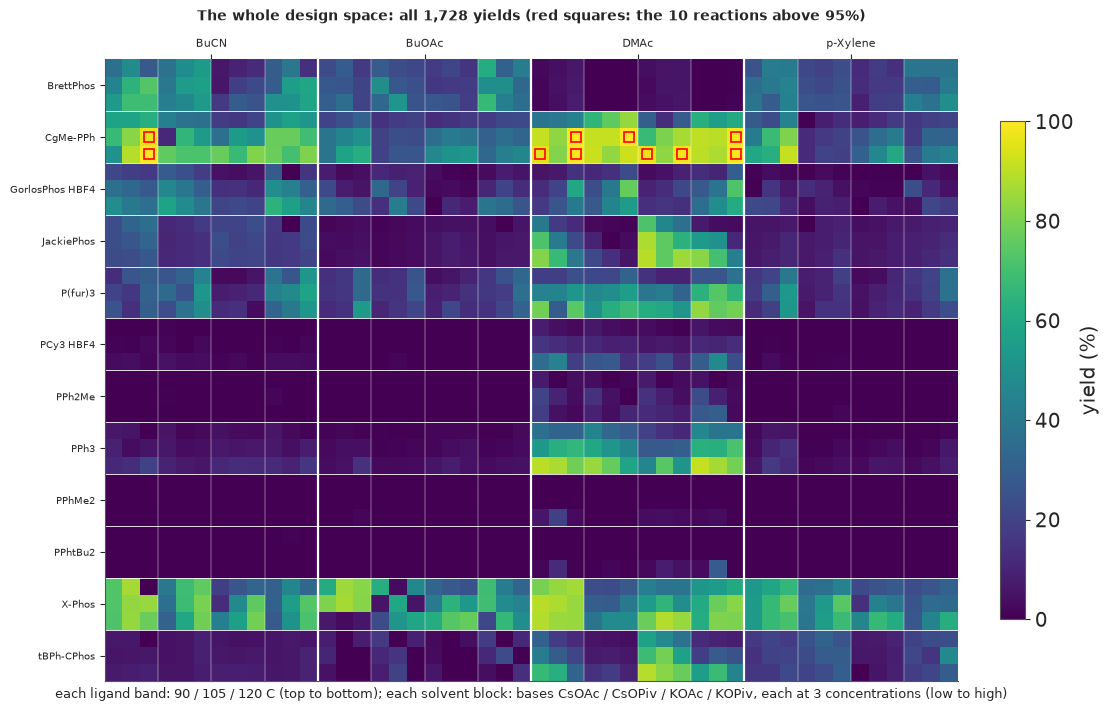

In [3]:
def to_grid(v):
    """Flat vector over the 1,728 reactions -> 36 x 48 image: rows ligand x temperature,
    columns solvent x base x concentration."""
    return np.asarray(v).reshape(NL).transpose(0, 4, 2, 1, 3).reshape(36, 48)


def grid_pos(i):
    """Row and column of reaction i in the to_grid image."""
    l, b, s, c, t = np.unravel_index(i, NL)
    return l * 3 + t, s * 12 + b * 3 + c


def draw_space(ax, v, cmap="viridis", vmin=None, vmax=None, labels=True, title=None, cbar=None):
    im = ax.imshow(to_grid(v), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto",
                   interpolation="nearest")
    for r in range(3, 36, 3):
        ax.axhline(r - 0.5, color="w", lw=0.6)
    for c in range(3, 48, 3):
        ax.axvline(c - 0.5, color="w", lw=0.3 if c % 12 else 1.6)
    ax.set_xticks([]), ax.set_yticks([])
    if labels:
        ax.set_yticks(np.arange(1, 36, 3), LEV[0], fontsize=7)
        ax.set_xticks(np.arange(5.5, 48, 12), LEV[2], fontsize=8)
        ax.xaxis.tick_top()
    if title:
        ax.set_xlabel(title, fontsize=9)
    if cbar is not None:
        plt.colorbar(im, ax=ax, shrink=0.8, label=cbar)
    return im


fig, ax = plt.subplots(figsize=(11, 7))
draw_space(ax, Y, vmin=0, vmax=100, cbar="yield (%)",
           title="each ligand band: 90 / 105 / 120 C (top to bottom); each solvent block: bases "
                 + " / ".join(LEV[1]) + ", each at 3 concentrations (low to high)")
best = np.argsort(Y)[-10:]
rr, cc = grid_pos(best)
ax.plot(cc, rr, "s", mfc="none", mec="red", ms=7, mew=1.2)
ax.set_title("The whole design space: all 1,728 yields (red squares: the 10 reactions above 95%)",
             fontsize=10, pad=28);

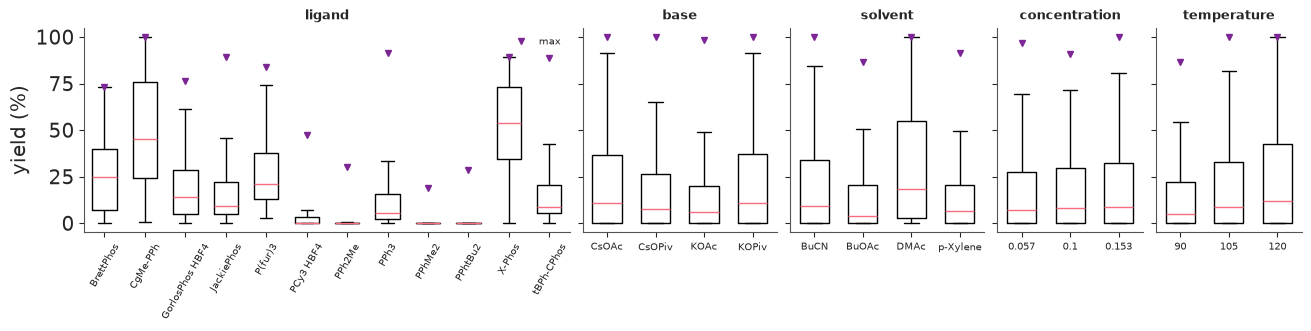

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(13, 3.2), sharey=True, width_ratios=[4, 1.6, 1.6, 1.2, 1.2])
for ax, f, lv in zip(axes, FACT, LEV):
    g = df.groupby(f)["yield"]
    parts = [df.loc[df[f] == l, "yield"].to_numpy() for l in lv]
    ax.boxplot(parts, widths=0.6, showfliers=False)
    ax.plot(np.arange(1, len(lv) + 1), g.max().reindex(lv), "v", color="C3", ms=5, label="max")
    ax.set_xticks(np.arange(1, len(lv) + 1), [str(l) for l in lv], rotation=60 if f == "ligand" else 0,
                  fontsize=7)
    ax.set_title(f, fontsize=9)
axes[0].set_ylabel("yield (%)")
axes[0].legend(fontsize=7);

In [5]:
def anova_r2(terms):
    """Share of the variance of the full table explained by the given main effects / interactions."""
    cols = [np.ones(N)]
    for t in terms:
        g = np.ravel_multi_index(IDX[:, list(t)].T, [NL[i] for i in t])
        cols.append(np.eye(g.max() + 1)[g])
    X = np.column_stack(cols)
    b = np.linalg.lstsq(X, Y, rcond=None)[0]
    return 1 - np.sum((Y - X @ b) ** 2) / np.sum((Y - Y.mean()) ** 2)


mains = [(f,) for f in range(5)]
pairs = [(a, b) for a in range(5) for b in range(a + 1, 5)]
r2_main, r2_two = anova_r2(mains), anova_r2(mains + pairs)
print(f"share of the variance of the 1,728 yields: main effects {r2_main:.2f}, "
      f"+ all two-factor interactions {r2_two:.2f}")
print("  single factors:", {FACT[f]: round(anova_r2([(f,)]), 3) for f in range(5)})
print("  largest interactions (added to the main effects):",
      sorted([(f"{FACT[a]} x {FACT[b]}", round(anova_r2(mains + [(a, b)]) - r2_main, 3)) for a, b in pairs],
             key=lambda x: -x[1])[:3])

share of the variance of the 1,728 yields: main effects 0.60, + all two-factor interactions 0.84
  single factors: {'ligand': np.float64(0.476), 'base': np.float64(0.013), 'solvent': np.float64(0.082), 'concentration': np.float64(0.002), 'temperature': np.float64(0.03)}
  largest interactions (added to the main effects): [('ligand x solvent', np.float64(0.143)), ('ligand x base', np.float64(0.037)), ('ligand x temperature', np.float64(0.021))]


The table is mostly failure: half the reactions give under 8%, 29% give nothing at all, and only 18
exceed 90%. All ten reactions above 95% use one ligand (**CgMe-PPh**), eight of them in **DMAc**. The
picture shows two kinds of structure a model can exploit:

* **main effects**: rows (ligands) differ enormously - four ligands (PCy3, PPh2Me, PPhMe2, PPhtBu2)
  average under 4% and never exceed 48%, while X-Phos and CgMe-PPh average about 50%; DMAc is the
  best solvent on average, and higher temperatures help a little;
* **interactions**: several ligands (JackiePhos, PPh3, tBPh-CPhos) work *only* in DMAc, and the best
  reactions need the right ligand in the right solvent.

A variance decomposition of the whole table (which no chemist has before starting) puts numbers on
this - main effects explain about 60% of the variance, the ligand alone about half, and the largest
interaction is ligand x solvent. We will not use these numbers to build the model; they are here to
judge afterwards what the model learned.

How well does **random search** do? For drawing $n$ reactions without replacement the answer is
exact: $P(\text{best} < y) = \binom{N - m_y}{n} / \binom{N}{n}$, where $m_y$ is the number of
reactions with yield at least $y$.

In [6]:
from scipy.special import gammaln


def random_search_cdf(n, y):
    """P(best of n reactions drawn without replacement < y), exactly (a hypergeometric count)."""
    m = np.sum(Y >= y)
    if n > N - m:
        return 0.0
    return np.exp(gammaln(N - m + 1) - gammaln(N - m - n + 1) - gammaln(N + 1) + gammaln(N - n + 1))


ns = np.arange(1, 101)
p95_random = np.array([1 - random_search_cdf(n, 95) for n in ns])
ys_sorted = np.sort(np.unique(Y))
med_random = np.array([ys_sorted[np.searchsorted([random_search_cdf(n, y) for y in ys_sorted], 0.5) - 1]
                       for n in ns])
for n in [10, 20, 30, 50, 100]:
    print(f"random search, {n:3d} reactions: median best {med_random[n - 1]:5.1f}%, "
          f"P(best >= 95%) = {p95_random[n - 1]:.2f}")

random search,  10 reactions: median best  69.3%, P(best >= 95%) = 0.06
random search,  20 reactions: median best  81.6%, P(best >= 95%) = 0.11
random search,  30 reactions: median best  84.7%, P(best >= 95%) = 0.16
random search,  50 reactions: median best  88.9%, P(best >= 95%) = 0.26
random search, 100 reactions: median best  92.0%, P(best >= 95%) = 0.45


## B. The surrogate: a Gaussian process over five kinds of factor

The inputs are not points in a space: three factors are **categorical** (there is no "distance"
between two ligands) and two are **continuous with three levels**. A convenient kernel for such a grid
is a product of one small correlation matrix per factor. For a factor $f$ with correlation parameter
$\rho_f \in (0, 1)$:

* categorical: $R_f(i, j) = 1$ if $i = j$, else $\rho_f$ (every pair of different ligands equally
  related - an *exchangeable* kernel);
* continuous: $R_f(i, j) = \rho_f^{\,(x_i - x_j)^2}$ with the levels scaled to [0, 1] - this is the
  familiar squared-exponential kernel with lengthscale $\ell = 1/\sqrt{-2\log\rho_f}$.

Writing both with $\rho_f$ = "the correlation between the yields of two reactions that differ only in
this factor (at its extremes, for a continuous one)" makes the prior readable: $\rho_f \sim
\mathrm{Beta}(2, 2)$ says "anything from nearly unrelated to nearly interchangeable, most likely
in between". A one-hot encoding with a squared-exponential kernel and one lengthscale per factor is
the same thing (checked below against `pm.gp.cov.ExpQuad`).

Two kernels:

* **product**: $k(x, x') = \eta^2 \prod_f R_f(x_f, x'_f)$ - every factor interacts with every other.
  This is what "one-hot + ARD kernel" gives by default.
* **additive + interactions**: the product term *plus* one **main-effect** kernel per factor,
  $\sum_f a_f^2 M_f(x_f, x'_f)$, with $M_f$ the identity for a categorical factor (a random effect
  per level - a hierarchical ANOVA, written as a GP) and $R_f$ for a continuous one. The amplitude
  $a_f$ says how much factor $f$ moves the yield on its own.

Yields are standardised with the mean and sd of the reactions run so far, so the priors are in sd
units: $a_f \sim$ HalfNormal(1), $\eta \sim$ HalfNormal(1.5), noise $\sigma \sim$ HalfNormal(0.5),
constant mean $c \sim$ Normal(0, 1). The likelihood is the GP marginal likelihood, written directly
as an `MvNormal` whose covariance indexes the small level matrices; `idx` and `y` are `pm.Data`, so the
same compiled model serves every campaign.

In [7]:
POS = [None, None, None,
       (np.array(LEV[3]) - LEV[3][0]) / (LEV[3][-1] - LEV[3][0]),   # concentration scaled to 0..1
       (np.array(LEV[4]) - LEV[4][0]) / (LEV[4][-1] - LEV[4][0])]   # temperature scaled to 0..1


def sq_dist(encoding="categorical", lig_desc=None):
    """Squared 'distances' between the levels of each factor (the kernel is rho ** d2)."""
    out = []
    for f in range(5):
        if f == 0 and encoding == "number":        # ligand as its position in an alphabetical list
            p = np.arange(NL[0]) / (NL[0] - 1)
            out.append((p[:, None] - p[None, :]) ** 2)
        elif f == 0 and encoding == "descriptors":
            out.append(lig_desc)
        elif POS[f] is None:                       # categorical: every pair of levels is 'distance 1'
            out.append(1.0 - np.eye(NL[f]))
        else:
            out.append((POS[f][:, None] - POS[f][None, :]) ** 2)
    return out


def gp_model(kernel="additive", encoding="categorical", lig_desc=None, n0=5):
    d2 = sq_dist(encoding, lig_desc)
    with pm.Model(coords={"factor": FACT}) as m:
        idx = pm.Data("idx", IDX[:n0])
        y = pm.Data("y", np.zeros(n0))
        c = pm.Normal("c", 0.0, 1.0)
        sigma = pm.HalfNormal("sigma", 0.5)
        rho = pm.Beta("rho", 2.0, 2.0, dims="factor")
        eta = pm.HalfNormal("eta", 1.5)
        K = eta**2                                  # interactions: a product over the factors
        for f in range(5):
            R = rho[f] ** pt.as_tensor(d2[f])
            K = K * R[idx[:, f][:, None], idx[:, f][None, :]]
        if kernel == "additive":                    # plus one main-effect kernel per factor
            amp = pm.HalfNormal("amp", 1.0, dims="factor")
            for f in range(5):
                Rm = pt.as_tensor(np.eye(NL[f])) if np.array_equal(d2[f], 1.0 - np.eye(NL[f])) \
                    else rho[f] ** pt.as_tensor(d2[f])
                K = K + amp[f] ** 2 * Rm[idx[:, f][:, None], idx[:, f][None, :]]
        cov = K + (sigma**2 + 1e-6) * pt.eye(idx.shape[0])
        pm.MvNormal("obs", mu=c, cov=cov, observed=y)
    return m, d2

Predictions over all 1,728 reactions need the same kernel in NumPy. Two facts keep everything cheap:
the posterior at all reactions needs only an $n \times n$ Cholesky factor ($n$ = reactions run), and on
the full grid the product kernel is a **Kronecker product** of the five level matrices, so an exact
*joint* draw of the whole surface needs five tiny Cholesky factors instead of one 1,728 x 1,728 one.
**Matheron's rule** turns a prior draw into a posterior draw: draw $f$ from the prior, then add
$K_{\ast X}(K_{XX} + \sigma^2 I)^{-1}(y - f(X) - \varepsilon)$ - the correction that makes the draw
agree with the data. Those joint draws are what Thompson sampling (Part C) needs.

In [8]:
def level_mats(h, d2):
    """Per-factor level correlation matrices: interaction (R) and main-effect (M) kernels."""
    R = [h["rho"][f] ** d2[f] for f in range(5)]
    M = [np.eye(NL[f]) if np.array_equal(d2[f], 1.0 - np.eye(NL[f])) else R[f] for f in range(5)]
    return R, M


def kern(h, d2, A, B):
    R, M = level_mats(h, d2)
    K = np.full((len(A), len(B)), h["eta"] ** 2)
    for f in range(5):
        K *= R[f][A[:, f][:, None], B[:, f][None, :]]
    if "amp" in h:
        for f in range(5):
            K += h["amp"][f] ** 2 * M[f][A[:, f][:, None], B[:, f][None, :]]
    return K


def prior_var(h):
    return h["eta"] ** 2 + (np.sum(h["amp"] ** 2) if "amp" in h else 0.0)


def gp_posterior(h, d2, sel, ys):
    """Posterior mean and sd of the latent yield surface (standardised units) on all 1,728 cells."""
    Xs = IDX[sel]
    L = np.linalg.cholesky(kern(h, d2, Xs, Xs) + (h["sigma"] ** 2 + 1e-6) * np.eye(len(sel)))
    Kgx = kern(h, d2, IDX, Xs)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, ys - h["c"]))
    V = np.linalg.solve(L, Kgx.T)
    sd = np.sqrt(np.maximum(prior_var(h) - np.sum(V**2, 0), 1e-12))
    return h["c"] + Kgx @ alpha, sd, (L, Kgx)


def prior_surface(h, d2, rng, k=1):
    """Draws of the surface on the whole grid. The interaction kernel is a Kronecker product of five
    small matrices, so a draw needs five tiny Cholesky factors instead of one 1,728 x 1,728 one."""
    R, M = level_mats(h, d2)
    LR = [np.linalg.cholesky(r + 1e-9 * np.eye(len(r))) for r in R]
    LM = [np.linalg.cholesky(r + 1e-9 * np.eye(len(r))) for r in M]
    out = np.empty((k, N))
    for j in range(k):
        z = rng.standard_normal(NL)
        for f in range(5):
            z = np.moveaxis(np.tensordot(LR[f], z, axes=([1], [f])), 0, f)
        s = h["eta"] * z.reshape(-1)
        if "amp" in h:
            for f in range(5):
                s += h["amp"][f] * (LM[f] @ rng.standard_normal(NL[f]))[IDX[:, f]]
        out[j] = h["c"] + s
    return out


def posterior_surface(h, d2, sel, ys, cache, rng, k=1):
    """Posterior draws by Matheron's rule: a prior draw, corrected by what it got wrong at the data."""
    L, Kgx = cache
    fp = prior_surface(h, d2, rng, k)
    eps = h["sigma"] * rng.standard_normal((k, len(sel)))
    resid = ys[None, :] - fp[:, sel] - eps
    a = np.linalg.solve(L.T, np.linalg.solve(L, resid.T))
    return fp + (Kgx @ a).T

In [9]:
# Check 1: the index-based kernel equals PyMC's own ExpQuad on a one-hot (+ scaled continuous) design.
h_chk = {"rho": np.array([0.3, 0.6, 0.5, 0.7, 0.4]), "eta": 1.3}
pick = rng.choice(N, 25, replace=False)
blocks = [np.eye(NL[f])[IDX[pick, f]] if POS[f] is None else POS[f][IDX[pick, f]][:, None] for f in range(5)]
X_onehot = np.column_stack(blocks)
edges_ = np.cumsum([0] + [b.shape[1] for b in blocks])
cov = h_chk["eta"] ** 2
for f in range(5):
    r_ = h_chk["rho"][f]
    ls = 1 / np.sqrt(-np.log(r_)) if POS[f] is None else 1 / np.sqrt(-2 * np.log(r_))
    cov = cov * pm.gp.cov.ExpQuad(X_onehot.shape[1], ls=ls, active_dims=list(range(edges_[f], edges_[f + 1])))
K_pm = cov(X_onehot).eval()                       # 25 x 25: small enough for .eval()
print("max |pm.gp.cov.ExpQuad - index kernel| =", np.abs(K_pm - kern(h_chk, sq_dist(), IDX[pick], IDX[pick])).max())

max |pm.gp.cov.ExpQuad - index kernel| = 3.3306690738754696e-16


Check 1 agrees to rounding error. Now the **prior predictive**: what kinds of yield surface does the
prior consider plausible before any reaction is run? Each draw below is standardised and drawn in the
same layout as the real table (top left).

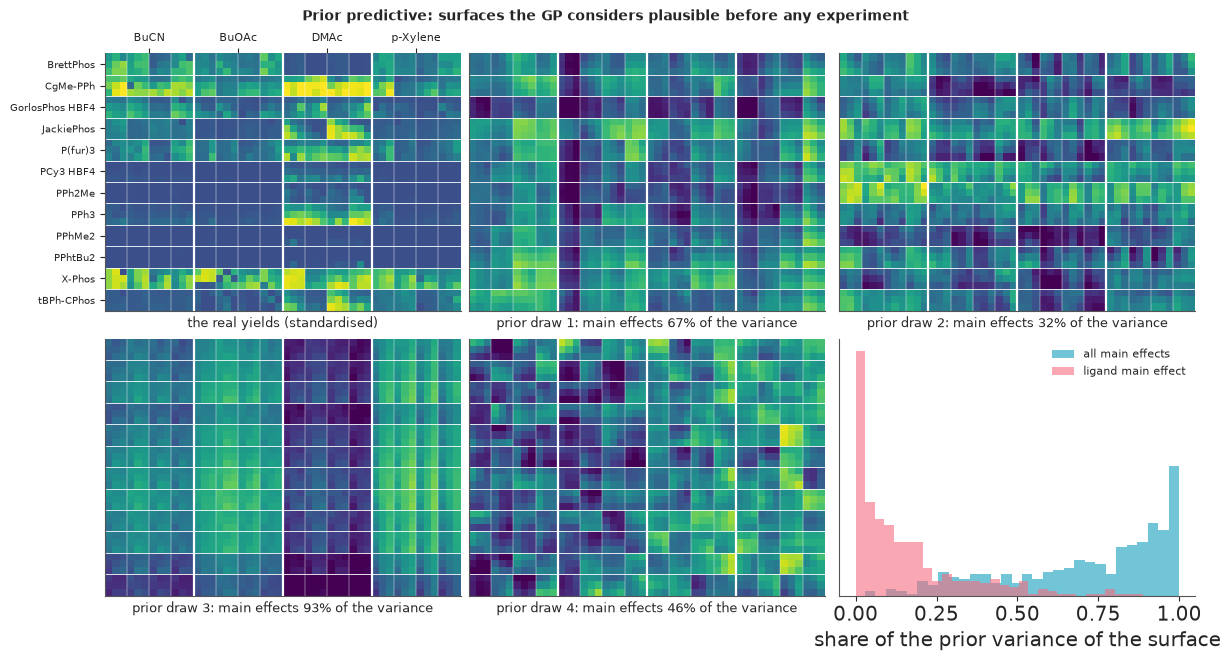

In [10]:
m_prior, d2_cat = gp_model("additive")
prior_h = pm.draw([m_prior[v] for v in ["c", "sigma", "rho", "eta", "amp"]], draws=400,
                  random_seed=RANDOM_SEED)
prior_h = [dict(zip(["c", "sigma", "rho", "eta", "amp"], [p[i] for p in prior_h])) for i in range(400)]
share_main = np.array([np.sum(h["amp"] ** 2) / prior_var(h) for h in prior_h])
share_lig = np.array([h["amp"][0] ** 2 / prior_var(h) for h in prior_h])
ys_all = (Y - Y.mean()) / Y.std()

fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
draw_space(axes[0, 0], ys_all, cmap="viridis", vmin=-2, vmax=3, labels=True,
           title="the real yields (standardised)")
for ax, j in zip(axes.ravel()[1:5], [0, 1, 2, 3]):
    s = prior_surface(prior_h[j], d2_cat, np.random.default_rng(j), 1)[0]
    draw_space(ax, (s - s.mean()) / s.std(), vmin=-2, vmax=3, labels=False,
               title=f"prior draw {j + 1}: main effects {share_main[j]:.0%} of the variance")
ax = axes[1, 2]
ax.hist(share_main, bins=30, color="C0", alpha=0.7, label="all main effects")
ax.hist(share_lig, bins=30, color="C1", alpha=0.6, label="ligand main effect")
ax.set(xlabel="share of the prior variance of the surface", yticks=[])
ax.legend(fontsize=8)
fig.suptitle("Prior predictive: surfaces the GP considers plausible before any experiment", fontsize=10);

The draws range from surfaces dominated by main effects (stripes and bands: draw 3, where main effects
carry 93% of the variance) to patchy ones dominated by interactions (draw 2: 32%). The histogram shows
the prior's view of the share of variance due to main effects: spread over the whole range with a
mode near 1 - a deliberate lean towards "factors act mostly on their own", which the real table
supports (about 60%) without the prior being built from it. The ligand alone usually gets well under
a quarter of the variance in the prior (it treats the five factors alike), against about half in
reality: the data will have to teach the model that the ligand dominates.

### The loop, and a MAP shortcut

A campaign refits the surrogate after every reaction. The benchmarks below run 50 campaigns of up to
45 refits for each of 15 strategies - over 25,000 fits. NUTS takes a fraction of a second per fit
(Part E runs it 400 times), which is too slow for all of them, so the loop uses the **posterior mode
(MAP)** of the hyperparameters, found by L-BFGS on the PyMC model's own compiled log density and
gradient. The mode is taken on the sampler's unconstrained scale (log amplitudes, logit correlations),
which includes the Jacobian and keeps amplitudes from collapsing to zero. `pm.set_data` swaps in the
reactions run so far - arrays of a new length each time - without recompiling. The next section and
Part E check whether the shortcut changes what gets chosen.

In [11]:
T_BUDGET, N0 = 50, 5


def standardise(yv):
    s = yv.std()
    return (yv - yv.mean()) / (s if s > 0 else 1.0), yv.mean(), (s if s > 0 else 1.0)


class MapFitter:
    """Compile the PyMC model's log posterior and gradient ONCE; each refit swaps the data with
    pm.set_data (the arrays may change length) and runs L-BFGS on the unconstrained parameters."""

    def __init__(self, model, d2):
        self.m, self.d2 = model, d2
        self.fn = model.logp_dlogp_function(ravel_inputs=True)
        self.fn.set_extra_values({})
        ip = model.initial_point()
        rv = DictToArrayBijection.map({v.name: ip[v.name] for v in model.value_vars})
        self.x0, self.info = rv.data, rv.point_map_info
        self.x = self.x0.copy()

    def fit(self, sel, ys):
        pm.set_data({"idx": IDX[sel], "y": ys}, model=self.m)
        best = None
        for s in [self.x, self.x0]:                 # warm start, and the prior centre
            r = optimize.minimize(lambda q: tuple(-v for v in self.fn(q)), s, jac=True,
                                  method="L-BFGS-B")
            if best is None or r.fun < best.fun:
                best = r
        self.x = best.x
        return self.unpack(best.x)

    def unpack(self, x):
        h = {}
        for k, v in DictToArrayBijection.rmap(RaveledVars(x, self.info)).items():
            if k.endswith("_logodds__"):
                h[k[:-10]] = 1 / (1 + np.exp(-v))
            elif k.endswith("_log__"):
                h[k[:-6]] = np.exp(v)
            else:
                h[k] = v
        return h


def expected_improvement(mu, sd, best):
    z = (mu - best) / sd
    return (mu - best) * stats.norm.cdf(z) + sd * stats.norm.pdf(z)


def choose(acq, h, d2, sel, ys, mu, sd, cache, tested, rng, q=1):
    """The next q reactions. For q > 1: Thompson draws, or 'kriging believer' (pretend the
    posterior mean was observed, update, choose again)."""
    new = []
    if acq == "ts":
        draws = posterior_surface(h, d2, sel, ys, cache, rng, k=3 * q)
        for d in draws:
            d[tested] = -np.inf
            d[new] = -np.inf
            if np.argmax(d) not in new:
                new.append(int(np.argmax(d)))
            if len(new) == q:
                break
        return new
    s2, y2, mu2, sd2 = list(sel), ys.copy(), mu, sd
    for j in range(q):
        if acq == "ei":
            a = expected_improvement(mu2, sd2, ys.max())
        elif acq == "pi":
            a = stats.norm.cdf((mu2 - ys.max() - 0.01) / sd2)
        elif acq == "ucb":
            a = mu2 + 2.0 * sd2
        elif acq == "greedy":
            a = mu2.copy()
        a[tested] = -np.inf
        a[new] = -np.inf
        i = int(np.argmax(a))
        new.append(i)
        if j < q - 1:
            s2, y2 = s2 + [i], np.append(y2, mu2[i])
            mu2, sd2, _ = gp_posterior(h, d2, np.array(s2), y2)
    return new


def campaign(fitter, seed, acq="ei", q=1, T=T_BUDGET, noise_sd=0.0, incumbent="observed",
             keep_frames=False):
    """One optimisation campaign on the real table. Returns the chosen reactions in order, the
    yields seen, the largest EI in yield points before each choice, and the TRUE yield of the
    reaction the model would recommend (highest posterior mean among those run) at each step."""
    rng_c = np.random.default_rng(seed)
    sel = list(rng_c.choice(N, N0, replace=False))           # the same 5 starting reactions for
    y_obs = list(Y[sel] + noise_sd * rng_c.standard_normal(N0))  # every strategy with this seed
    fitter.x = fitter.x0.copy()
    out = {"max_ei": [], "rec": [], "frames": [], "hyper": []}
    while len(sel) < T:
        ys, m_y, s_y = standardise(np.array(y_obs))
        h = fitter.fit(np.array(sel), ys)
        mu, sd, cache = gp_posterior(h, fitter.d2, np.array(sel), ys)
        tested = np.zeros(N, bool)
        tested[sel] = True
        inc = ys.max() if incumbent == "observed" else mu[sel].max()
        e = expected_improvement(mu, sd, inc) * s_y
        e[tested] = 0.0
        out["max_ei"].append(e.max())
        out["rec"].append(Y[sel[int(np.argmax(mu[sel]))]])
        out["hyper"].append(h)
        if acq == "ei" and incumbent == "mean":        # EI against the best posterior mean (q = 1)
            new = [int(np.argmax(np.where(tested, -np.inf, e)))]
        else:
            new = choose(acq, h, fitter.d2, np.array(sel), ys, mu, sd, cache, tested, rng_c,
                         min(q, T - len(sel)))
        if keep_frames:
            out["frames"].append(dict(n=len(sel), mu=mu * s_y + m_y, sd=sd * s_y, ei=e, new=new,
                                      sel=list(sel)))
        sel += new
        y_obs += list(Y[new] + noise_sd * rng_c.standard_normal(len(new)))
    out.update(sel=np.array(sel[:T]), y_obs=np.array(y_obs[:T]))
    return out


fit_add = MapFitter(*gp_model("additive"))
tic = time.time()
demo = campaign(fit_add, seed=RANDOM_SEED, keep_frames=True)
print(f"one 50-reaction campaign (45 refits + choices): {time.time() - tic:.1f} s")
print("best yield after 5, 10, 15, 20, 30, 50 reactions:",
      [float(np.max(Y[demo['sel'][:n]])) for n in [5, 10, 15, 20, 30, 50]])

one 50-reaction campaign (45 refits + choices): 0.2 s
best yield after 5, 10, 15, 20, 30, 50 reactions: [40.02, 78.6, 80.86, 99.98, 100.0, 100.0]


### Inside one campaign: the surrogate after 15 reactions

The campaign above (seed 82) started from five random reactions, then chose ten by expected
improvement. Here we fit the same 15 reactions with NUTS, to see the full posterior, and compare it
with the MAP plug-in the loop used.

In [12]:
SNAP = 15
sel15 = demo["sel"][:SNAP]
ys15, m15, s15 = standardise(Y[sel15])
m_nuts, _ = gp_model("additive", n0=SNAP)
pm.set_data({"idx": IDX[sel15], "y": ys15}, model=m_nuts)
with m_nuts:
    idata15 = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(idata15, var_names=["c", "sigma", "eta", "amp", "rho"], round_to=2)
      [["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]].to_string())
print("divergences:", int(idata15.sample_stats["diverging"].sum()),
      "| tuning steps:", idata15.posterior.attrs.get("tuning_steps"))

                    mean    sd  eti89_lb  eti89_ub  ess_bulk  r_hat
c                  -0.34  0.75     -1.49      0.92   5015.70   1.00
sigma               0.19  0.15      0.02      0.46   1655.11   1.00
eta                 0.38  0.28      0.04      0.91   1469.59   1.01
amp[ligand]         0.79  0.34      0.30      1.35   2119.57   1.00
amp[base]           0.21  0.22      0.01      0.63   3980.11   1.00
amp[solvent]        0.52  0.40      0.05      1.25   2875.22   1.00
amp[concentration]  0.94  0.52      0.20      1.86   1751.62   1.00
amp[temperature]    0.56  0.48      0.04      1.47   3116.35   1.00
rho[ligand]         0.47  0.22      0.13      0.83   6064.88   1.00
rho[base]           0.58  0.23      0.19      0.91   4696.22   1.00
rho[solvent]        0.51  0.22      0.14      0.86   6375.33   1.00
rho[concentration]  0.45  0.21      0.13      0.80   6022.42   1.00
rho[temperature]    0.53  0.23      0.16      0.88   6079.07   1.00
divergences: 0 | tuning steps: 400


In [13]:
h_map15 = MapFitter(*gp_model("additive")).fit(sel15, ys15)
print("MAP:", {k: np.round(v, 2) for k, v in h_map15.items()})
post = az.extract(idata15, num_samples=300, random_seed=RANDOM_SEED)
draws_h = [{k: post[k].values[..., i] for k in ["c", "sigma", "eta", "amp", "rho"]} for i in range(300)]
MU, VAR, EIs = [], [], []
for h in draws_h:
    mu, sd, _ = gp_posterior(h, d2_cat, sel15, ys15)
    MU.append(mu), VAR.append(sd**2)
    EIs.append(expected_improvement(mu, sd, ys15.max()))
MU, VAR = np.array(MU), np.array(VAR)
mu_full = MU.mean(0) * s15 + m15
sd_full = np.sqrt(VAR.mean(0) + MU.var(0)) * s15             # law of total variance over hyperparameters
ei_full = np.mean(EIs, 0) * s15
mu_map, sd_map, _ = gp_posterior(h_map15, d2_cat, sel15, ys15)
ei_map = expected_improvement(mu_map, sd_map, ys15.max()) * s15
mu_map, sd_map = mu_map * s15 + m15, sd_map * s15
untested = np.setdiff1d(np.arange(N), sel15)
top_full = untested[np.argsort(ei_full[untested])[-10:]]
top_map = untested[np.argsort(ei_map[untested])[-10:]]
print(f"posterior mean, MAP vs full: corr {np.corrcoef(mu_map, mu_full)[0, 1]:.3f}, "
      f"max |diff| {np.max(np.abs(mu_map - mu_full)):.1f} points")
print(f"posterior sd: MAP / full, median ratio {np.median(sd_map / sd_full):.2f} "
      f"(5-95%: {np.quantile(sd_map / sd_full, 0.05):.2f}-{np.quantile(sd_map / sd_full, 0.95):.2f})")
print(f"EI: Spearman rank corr {stats.spearmanr(ei_map[untested], ei_full[untested])[0]:.3f}; "
      f"same first choice: {top_map[-1] == top_full[-1]}; top-10 overlap: {len(set(top_map) & set(top_full))}")

MAP: {'c': np.float64(-0.42), 'sigma': np.float64(0.16), 'rho': array([0.49, 0.57, 0.5 , 0.46, 0.55]), 'eta': np.float64(0.24), 'amp': array([0.77, 0.14, 0.57, 0.92, 0.49])}


posterior mean, MAP vs full: corr 0.986, max |diff| 17.3 points
posterior sd: MAP / full, median ratio 0.76 (5-95%: 0.62-0.83)
EI: Spearman rank corr 0.965; same first choice: False; top-10 overlap: 5


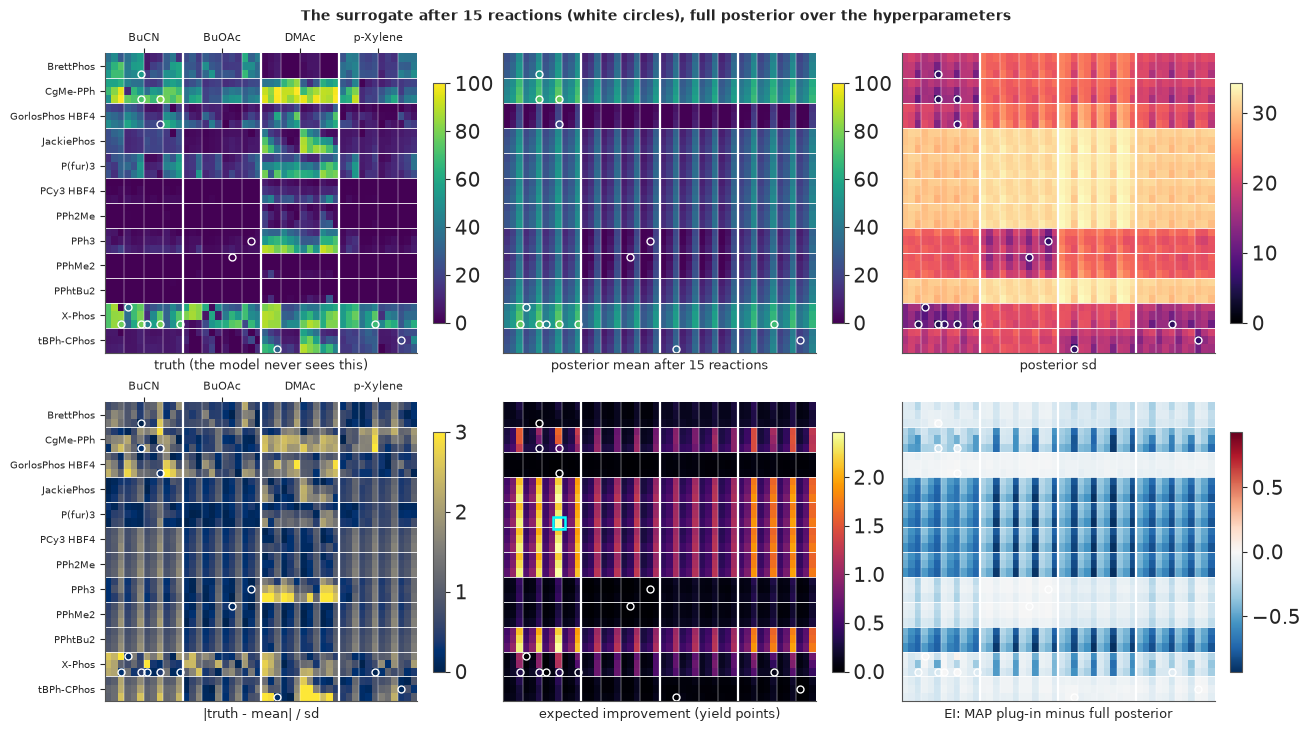

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.2))
rr, cc = grid_pos(sel15)
for ax, v, t, cm, lim in [
        (axes[0, 0], Y, "truth (the model never sees this)", "viridis", (0, 100)),
        (axes[0, 1], mu_full, "posterior mean after 15 reactions", "viridis", (0, 100)),
        (axes[0, 2], sd_full, "posterior sd", "magma", (0, None)),
        (axes[1, 0], np.abs(mu_full - Y) / sd_full, "|truth - mean| / sd", "cividis", (0, 3)),
        (axes[1, 1], ei_full, "expected improvement (yield points)", "inferno", (0, None)),
        (axes[1, 2], ei_map - ei_full, "EI: MAP plug-in minus full posterior", "RdBu_r", None)]:
    if lim is None:
        a = np.max(np.abs(v))
        lim = (-a, a)
    draw_space(ax, v, cmap=cm, vmin=lim[0], vmax=lim[1], labels=ax in axes[:, 0], title=t, cbar="")
    ax.plot(cc, rr, "o", mfc="none", mec="w", ms=5, mew=1.0)
r1, c1 = grid_pos(top_full[-1])
axes[1, 1].plot(c1, r1, "s", mfc="none", mec="cyan", ms=9, mew=1.8)
fig.suptitle("The surrogate after 15 reactions (white circles), full posterior over the hyperparameters",
             fontsize=10);

What the numbers and the panels say:

* **Sampling is clean** (no divergences at `target_accept=0.95`, $\hat R \le 1.01$). The correlations
  $\rho_f$ have barely moved from their Beta(2, 2) prior: 15 reactions say little about how factors
  interact. The ligand amplitude is clearly non-zero; the concentration amplitude is the largest
  *and* the least certain - with 15 reactions the model thinks concentration might matter, which the
  full table says it hardly does. That is not a bug: it is what 15 reactions support.
* **Posterior mean** (top middle): ligands that have been tried have their own level; the untested
  ones sit at the overall mean with a posterior sd of about 30 points (top right). The vertical
  stripes are the main effects of concentration and base the model has inferred.
* **Calibration** (bottom left): most reactions are within 2 sd of the posterior mean; the largest
  misses (2-3 sd) are the reactions that work only in DMAc (CgMe-PPh, PPh3, tBPh-CPhos there) -
  interactions nothing so far has hinted at.
* **Expected improvement** (bottom middle): large for the untested ligands, at the base and
  concentration the model currently likes; the cyan square is the top choice.
* **MAP vs full posterior**: the posterior means agree closely (correlation about 0.99), but the MAP
  plug-in's sd is about a quarter too small (it ignores uncertainty in the hyperparameters), so its EI
  is lower almost everywhere (bottom right) and its ranking differs in detail - the rank correlation of
  EI is about 0.97, but the first choice and half of the top ten differ. Whether that matters for a
  whole campaign is tested in Part E.

## C. Acquisition functions: turning a posterior into a choice

With $y^\ast$ the best standardised yield so far and $\mu(x), s(x)$ the posterior mean and sd of the
latent yield at reaction $x$:

* **Expected improvement**: $\mathrm{EI}(x) = E[\max(f(x) - y^\ast, 0)] = (\mu - y^\ast)\Phi(z) + s\,\phi(z)$,
  $z = (\mu - y^\ast)/s$. Large where the mean is high *or* the sd is large; in yield points, it is the
  expected gain over the best so far from running $x$ next.
* **Probability of improvement**: $\Phi((\mu - y^\ast - \xi)/s)$ with a small $\xi$: the chance of
  beating the best at all, however slightly.
* **Upper confidence bound**: $\mu + \kappa s$, here $\kappa = 2$ ("optimism in the face of uncertainty").
* **Thompson sampling**: draw one whole surface from the posterior and run its maximum. Each draw
  is a plausible version of the truth; choosing its best reaction explores exactly as often as the
  posterior says a reaction *could* be best.

Here EI is averaged over the NUTS draws of the hyperparameters (the fully Bayesian version); PI and
UCB use the posterior mean and sd of the mixture; each Thompson draw uses one hyperparameter draw.

true yield of each rule's first choice: {'expected improvement': 20.72, 'probability of improvement': 50.75, 'upper confidence bound (mean + 2 sd)': 20.72}


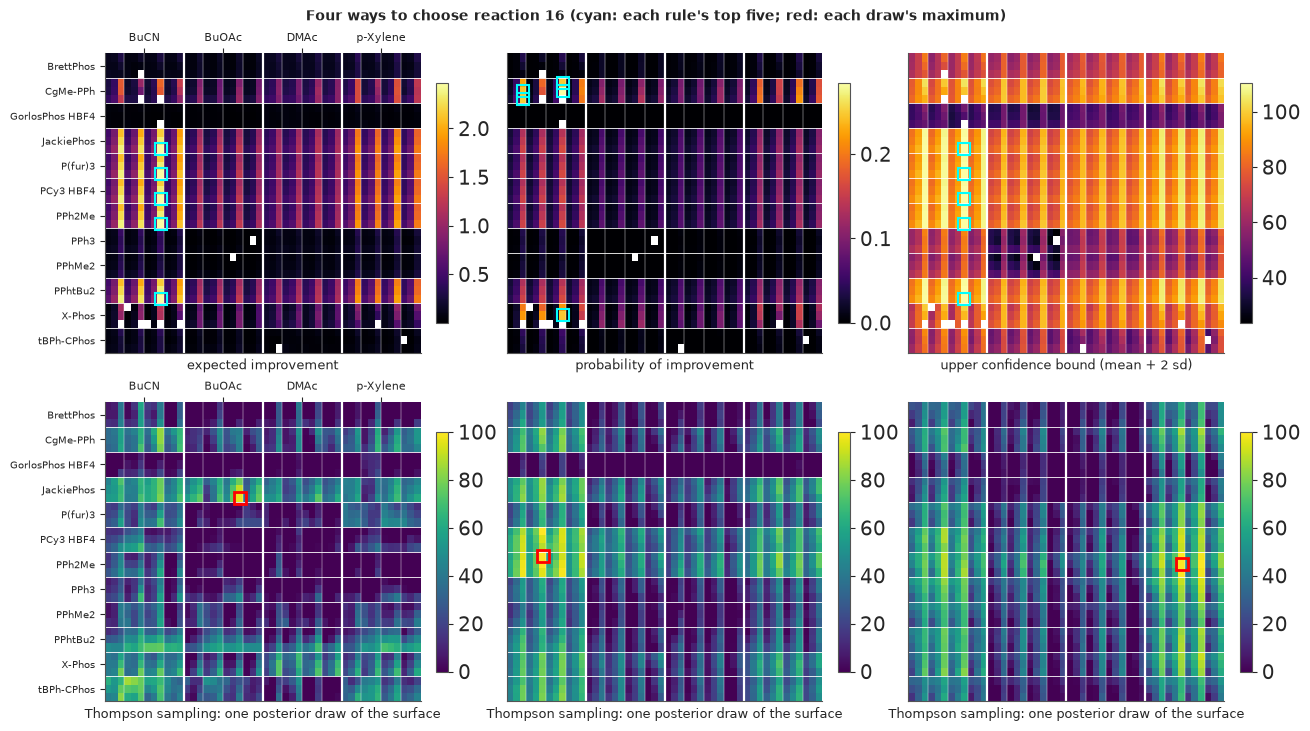

In [15]:
mu_s, sd_s = (mu_full - m15) / s15, sd_full / s15
acqs = {
    "expected improvement": ei_full,
    "probability of improvement": stats.norm.cdf((mu_s - ys15.max() - 0.01) / sd_s),
    "upper confidence bound (mean + 2 sd)": mu_full + 2 * sd_full,
}
ts_draws = []
for h in draws_h[:4]:
    mu_h, sd_h, cache = gp_posterior(h, d2_cat, sel15, ys15)
    ts_draws.append(posterior_surface(h, d2_cat, sel15, ys15, cache, np.random.default_rng(len(ts_draws)))[0]
                    * s15 + m15)
fig, axes = plt.subplots(2, 3, figsize=(13, 7.2))
for ax, (name, a) in zip(axes[0], acqs.items()):
    a = a.copy()
    a[sel15] = np.nan
    draw_space(ax, a, cmap="inferno", labels=ax is axes[0, 0], title=name, cbar="")
    top = untested[np.argsort(np.nan_to_num(a[untested], nan=-np.inf))[-5:]]
    r, c = grid_pos(top)
    ax.plot(c, r, "s", mfc="none", mec="cyan", ms=8, mew=1.5)
for ax, d in zip(axes[1], ts_draws[:3]):
    draw_space(ax, d, vmin=0, vmax=100, labels=ax is axes[1, 0],
               title="Thompson sampling: one posterior draw of the surface", cbar="")
    dd = d.copy()
    dd[sel15] = -np.inf
    r, c = grid_pos(int(np.argmax(dd)))
    ax.plot(c, r, "s", mfc="none", mec="red", ms=9, mew=2)
fig.suptitle("Four ways to choose reaction 16 (cyan: each rule's top five; red: each draw's maximum)",
             fontsize=10)
print("true yield of each rule's first choice:",
      {k: float(Y[untested[np.argmax(np.nan_to_num(v[untested], nan=-np.inf))]]) for k, v in acqs.items()})

In [16]:
# Check 2: Matheron's rule reproduces the closed-form posterior (2,000 draws, one set of hyperparameters).
h0 = draws_h[0]
mu0, sd0, cache0 = gp_posterior(h0, d2_cat, sel15, ys15)
dr0 = posterior_surface(h0, d2_cat, sel15, ys15, cache0, np.random.default_rng(1), k=2000)
print(f"|mean of draws - posterior mean| / sd: max {np.max(np.abs(dr0.mean(0) - mu0) / sd0):.3f} "
      f"(Monte Carlo error alone ~ {4 / np.sqrt(2000):.3f}); sd of draws / posterior sd: "
      f"{np.min(dr0.std(0) / sd0):.3f}-{np.max(dr0.std(0) / sd0):.3f}")
del dr0

|mean of draws - posterior mean| / sd: max 0.067 (Monte Carlo error alone ~ 0.089); sd of draws / posterior sd: 0.946-1.043


Check 2 passes: 2,000 Matheron draws reproduce the closed-form mean and sd within Monte Carlo error.

The four rules disagree in instructive ways. **EI** and **UCB** pick the same place: untested ligands
(JackiePhos, P(fur)3, PCy3, PPh2Me, PPhtBu2) in butyronitrile, where the sd is large. **PI** picks
reactions right next to the best so far (CgMe-PPh and X-Phos in BuCN): it only asks whether a reaction
beats the incumbent, not by how much, so a near-certain tiny gain wins - PI's well-known greed. Each
**Thompson** draw is a different plausible world with its maximum somewhere else. The true yields of
the first choices (21% for EI and UCB, 51% for PI) say nothing about which rule is better over a
campaign; Part F answers that.

## D. One campaign, step by step

The animation shows the same campaign (seed 82), from 5 to 48 reactions (every reaction up to 24,
then every other one). Panels: posterior mean yield, posterior sd, and expected improvement (MAP
plug-in, in yield points), all over the 1,728 reactions laid out as in Part A. White circles are
reactions already run, the cyan square is the next choice; on the right, the best yield so far.

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 4.2), dpi=72, width_ratios=[1, 1, 1, 0.8], layout="none")
fig.subplots_adjust(left=0.08, right=0.98, top=0.84, bottom=0.12, wspace=0.16)
fr0 = demo["frames"][0]
ims = [draw_space(axes[0], fr0["mu"], vmin=0, vmax=100, labels=True),
       draw_space(axes[1], fr0["sd"], cmap="magma", vmin=0, vmax=40, labels=False),
       draw_space(axes[2], fr0["ei"], cmap="inferno", vmin=0, vmax=5, labels=False)]
for ax in axes[:3]:
    for lab in ax.get_yticklabels():
        lab.set_fontsize(6)
titles = ["posterior mean yield (0-100%)", "posterior sd (0-40 points)", "expected improvement (0-5 points)"]
dots = [ax.plot([], [], "o", mfc="none", mec="w", ms=3.5, mew=0.8)[0] for ax in axes[:3]]
nxt = [ax.plot([], [], "s", mfc="none", mec="cyan", ms=7, mew=1.6)[0] for ax in axes[:3]]
best_curve = np.maximum.accumulate(Y[demo["sel"]])
axes[3].plot(np.arange(1, T_BUDGET + 1), best_curve, color="0.7")
cur, = axes[3].plot([], [], color="C0", lw=2)
axes[3].axhline(Y.max(), color="k", ls=":", lw=0.8)
axes[3].set(xlim=(0, T_BUDGET), ylim=(0, 105), xlabel="reactions run", title="best yield so far")
axes[3].title.set_fontsize(9)


def update(k):
    fr = demo["frames"][k]
    for im, v in zip(ims, [fr["mu"], fr["sd"], fr["ei"]]):
        im.set_data(to_grid(v))
    r, c = grid_pos(np.array(fr["sel"]))
    rn, cn = grid_pos(np.array(fr["new"]))
    for d_, n_ in zip(dots, nxt):
        d_.set_data(c, r)
        n_.set_data(cn, rn)
    for ax, t in zip(axes, titles):
        ax.set_title(t, fontsize=8, pad=14)
    cur.set_data(np.arange(1, fr["n"] + 1), best_curve[: fr["n"]])
    fig.suptitle(f"after {fr['n']} reactions: best {best_curve[fr['n'] - 1]:.0f}%, "
                 f"largest EI {fr['ei'].max():.1f} points; cyan = reaction {fr['n'] + 1}", fontsize=10)
    return ims + dots + nxt + [cur]


FRAMES = list(range(0, 20)) + list(range(21, len(demo["frames"]), 2))   # every step to 25, then every other
anim = animation.FuncAnimation(fig, update, frames=FRAMES, interval=500)
plt.close(fig)
_fmt = plt.rcParams["animation.frame_format"]
plt.rcParams["animation.frame_format"] = "jpeg"     # heatmaps: JPEG frames are far smaller than PNG
display(HTML(anim.to_jshtml(default_mode="once")))
plt.rcParams["animation.frame_format"] = _fmt
seq = df.loc[demo["sel"][:24], FACT + ["yield"]].assign(n=np.arange(1, 25)).set_index("n")
print(seq.to_string())

             ligand    base   solvent  concentration  temperature  yield
n                                                                       
1            PPhMe2    KOAc     BuOAc          0.100           90   0.00
2        tBPh-CPhos   CsOAc      DMAc          0.153          120  32.21
3              PPh3   KOPiv     BuOAc          0.100          105   1.92
4            X-Phos  CsOPiv      BuCN          0.057           90  40.02
5        tBPh-CPhos   KOPiv  p-Xylene          0.057          105  21.43
6            X-Phos  CsOPiv      BuCN          0.153          120  78.44
7         BrettPhos  CsOPiv      BuCN          0.153          120  53.81
8            X-Phos  CsOPiv  p-Xylene          0.153          120  68.31
9            X-Phos    KOAc      BuCN          0.153          120  78.60
10           X-Phos   CsOAc      BuCN          0.153          120  77.01
11           X-Phos   KOPiv      BuCN          0.153          120  71.43
12           X-Phos    KOAc      BuCN          0.05

The printed list is the same campaign as a table. Read it with the animation:

* **Reactions 1-5** are random; the best is X-Phos in butyronitrile (BuCN) at 40%. With five points the
  posterior mean is almost flat and EI is spread over whole solvent blocks.
* **Reaction 6** moves X-Phos in BuCN to the highest concentration and temperature: 78%. Reaction 7
  tries BrettPhos under the same conditions (54%); reactions 8-12 vary X-Phos's base, solvent and
  concentration (43-79%).
* **Reactions 13-17** carry those conditions to other ligands - CgMe-PPh (81%), GorlosPhos and
  JackiePhos (about 20% each) - and vary CgMe-PPh's base and temperature (72%, and 20% at 90 C).
  With an additive kernel, "0.153 M and 120 C are good" transfers to ligands never tried.
* **Reactions 18-20** concentrate on CgMe-PPh: 91% in p-xylene with CsOAc, 44% with KOPiv, then
  **99.98%** in BuCN with CsOAc - one of the best reactions in the table, at reaction 20.
* Afterwards the largest EI stays near or below one yield point. The campaign keeps varying CgMe-PPh
  and X-Phos and, by reaction 30, has also found the 100% reactions in DMAc (bright in the mean panel).

Notice the sd panel: it collapses around CgMe-PPh and X-Phos, which the campaign keeps returning to,
and stays large for the ten ligands tried only once or twice in 50 reactions - the campaign learns
where the best reactions are, not what every ligand does (Part J).

## E. Does it work? Many campaigns against random search, one-factor-at-a-time and chemists

Each strategy runs **50 campaigns** of 50 reactions. Campaign $i$ of every strategy starts from the
same five random reactions (seed $1000 + i$), so strategies can be compared *pairwise* - differences
are then not blurred by lucky or unlucky starts. The baselines:

* **random search**: the exact median curve from Part A, and 50 simulated campaigns;
* **one factor at a time** (OFAT), a classic human strategy: from the best of the five starting
  reactions, try every ligand with the other factors fixed, keep the best; then every base, solvent,
  temperature and concentration; repeat;
* **the chemists** in Shields et al.'s game, in the order they chose. They stopped after 10 to 100
  reactions, so we show both "those still playing" and "best kept after stopping";
* **the authors' own simulations** of their method (EDBO: a GP with expected improvement, batches of
  5), as published in their repository.

In [18]:
NCAMP = 50
SEEDS = 1000 + np.arange(NCAMP)


def run_many(fitter, **kw):
    return [campaign(fitter, s, **kw) for s in SEEDS]


def best_curves(runs):
    return np.array([np.maximum.accumulate(Y[r["sel"]]) for r in runs])


def run_random(seed):
    rng_c = np.random.default_rng(seed)
    first = rng_c.choice(N, N0, replace=False)
    rest = np.setdiff1d(np.arange(N), first)
    return np.r_[first, rng_c.permutation(rest)[: T_BUDGET - N0]]


def run_ofat(seed):
    """One factor at a time from the best of the same 5 starting reactions: try every level of the
    ligand, keep the best, then base, solvent, temperature, concentration; repeat the cycle."""
    rng_c = np.random.default_rng(seed)
    sel = list(rng_c.choice(N, N0, replace=False))
    while len(sel) < T_BUDGET:
        grew = False
        for f in [0, 1, 2, 4, 3]:
            cur = IDX[sel[int(np.argmax(Y[sel]))]].copy()
            for lv in range(NL[f]):
                c = cur.copy()
                c[f] = lv
                i = int(np.ravel_multi_index(tuple(c), NL))
                if i not in sel and len(sel) < T_BUDGET:
                    sel.append(i)
                    grew = True
        if not grew:
            sel.append(int(rng_c.choice(np.setdiff1d(np.arange(N), sel))))
    return np.array(sel)


tic = time.time()
fit_prod = MapFitter(*gp_model("product"))
RUNS = {"BO: EI, additive kernel": run_many(fit_add, acq="ei"),
        "BO: EI, product kernel": run_many(fit_prod, acq="ei")}
print(f"2 x {NCAMP} BO campaigns: {time.time() - tic:.0f} s")
CURVES = {k: best_curves(v) for k, v in RUNS.items()}
CURVES["random search"] = np.array([np.maximum.accumulate(Y[run_random(s)]) for s in SEEDS])
CURVES["one factor at a time"] = np.array([np.maximum.accumulate(Y[run_ofat(s)]) for s in SEEDS])

2 x 50 BO campaigns: 14 s


In [19]:
game = data.load("edbo_arylation_game")
data.describe("edbo_arylation_game")
H = np.full((game.participant.nunique(), 100), np.nan)
for p, g in game.groupby("participant"):
    H[p, : len(g)] = np.maximum.accumulate(g.sort_values("step")["yield"].to_numpy())
n_play = np.sum(~np.isnan(H), 0)
H_carry = pd.DataFrame(H).ffill(axis=1).to_numpy()      # a chemist who stopped keeps their best
edbo = data.load("edbo_arylation_edbo_runs")
E = np.maximum.accumulate(edbo.pivot(index="run", columns="step", values="yield").to_numpy(), axis=1)
print(f"chemists: {len(H)}, reactions each: median {np.median(n_play.sum() / len(H)):.0f} "
      f"(still playing at 10/20/30/50: {n_play[9]}, {n_play[19]}, {n_play[29]}, {n_play[49]})")


def summarise(C, ns=(10, 20, 30, 50)):
    row = {}
    for n in ns:
        if n > C.shape[1]:
            continue
        v = C[:, n - 1]
        v = v[~np.isnan(v)]
        k = np.sum(v >= 95)
        lo, hi = stats.beta(1 + k, 1 + len(v) - k).ppf([0.05, 0.95])
        row[f"median best @{n}"] = np.median(v)
        row[f"P(>=95%) @{n}"] = f"{k / len(v):.2f} [{lo:.2f}, {hi:.2f}]"
    return row


tab = {"random search (exact)": {**{f"median best @{n}": med_random[n - 1] for n in (10, 20, 30, 50)},
                                 **{f"P(>=95%) @{n}": f"{p95_random[n - 1]:.2f}" for n in (10, 20, 30, 50)}}}
for k, C in CURVES.items():
    tab[k] = summarise(C)
tab["chemists (if they had stopped: best kept)"] = summarise(H_carry)
tab["EDBO's own simulations (batches of 5)"] = summarise(E)
TAB = pd.DataFrame(tab).T
print(TAB[[c for c in TAB.columns if c.startswith("median")]].round(1).to_string())
print(TAB[[c for c in TAB.columns if c.startswith("P(")]].to_string())

edbo_arylation_game: 1,548 experiments by 50 participants (10-100 each): participant (0-49), area (Pharma, Academic, Other), expertise, experience (as self-reported), step (order played), ligand, base, solvent, concentration, temperature, yield.
  source: As edbo_arylation: the 'reaction optimisation game' of Shields et al. (2021), in which chemists chose experiments on the same grid and were shown the recorded yields. BUILT (reshaped to long format) by tools/build_e82_arylation.py.
  url:    https://raw.githubusercontent.com/b-shields/edbo/master/experiments/arylation_game_summary.csv
chemists: 50, reactions each: median 31 (still playing at 10/20/30/50: 50, 40, 23, 7)
                                          median best @10 median best @20 median best @30 median best @50
random search (exact)                               69.26           81.63           84.67           88.89
BO: EI, additive kernel                            80.625           99.81           99.98           100.0
BO:

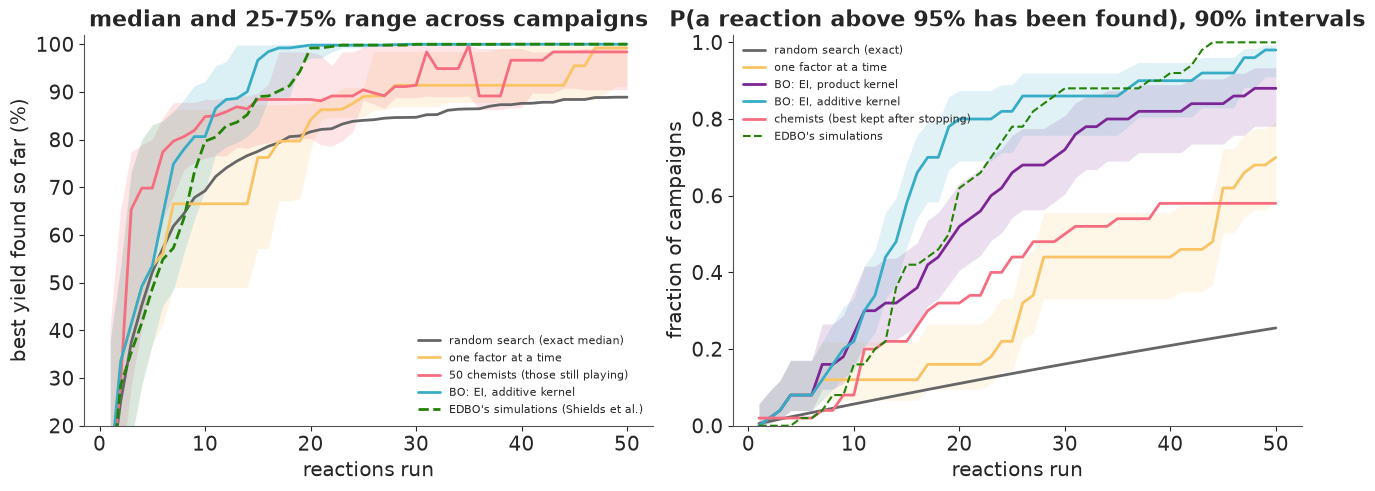

In [20]:
def band(ax, C, label, color, ls="-", q=(0.25, 0.75), fill=True):
    x = np.arange(1, C.shape[1] + 1)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        med = np.nanmedian(C, 0)
        lo, hi = np.nanquantile(C, q[0], 0), np.nanquantile(C, q[1], 0)
    ax.plot(x, med, color=color, ls=ls, lw=2, label=label)
    if fill:
        ax.fill_between(x, lo, hi, color=color, alpha=0.18, lw=0)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
ax.plot(ns[:T_BUDGET], med_random[:T_BUDGET], color="0.4", lw=2, label="random search (exact median)")
band(ax, CURVES["one factor at a time"], "one factor at a time", "C2")
band(ax, H[:, :T_BUDGET], "50 chemists (those still playing)", "C1")
band(ax, CURVES["BO: EI, additive kernel"], "BO: EI, additive kernel", "C0")
band(ax, E[:, :T_BUDGET], "EDBO's simulations (Shields et al.)", "C4", ls="--", fill=False)
ax.set(xlabel="reactions run", ylabel="best yield found so far (%)", ylim=(20, 102),
       title="median and 25-75% range across campaigns")
ax.legend(fontsize=8, loc="lower right")
ax = axes[1]
ax.plot(ns[:T_BUDGET], p95_random[:T_BUDGET], color="0.4", lw=2, label="random search (exact)")
for k, col in [("one factor at a time", "C2"), ("BO: EI, product kernel", "C3"),
               ("BO: EI, additive kernel", "C0")]:
    C = CURVES[k]
    kk = np.sum(C >= 95, 0)
    lo, hi = stats.beta(1 + kk, 1 + len(C) - kk).ppf([[0.05], [0.95]])
    ax.plot(np.arange(1, T_BUDGET + 1), kk / len(C), color=col, lw=2, label=k)
    ax.fill_between(np.arange(1, T_BUDGET + 1), lo, hi, color=col, alpha=0.15, lw=0)
ax.plot(np.arange(1, T_BUDGET + 1), np.mean(H_carry[:, :T_BUDGET] >= 95, 0), color="C1", lw=2,
        label="chemists (best kept after stopping)")
ax.plot(np.arange(1, T_BUDGET + 1), np.mean(E[:, :T_BUDGET] >= 95, 0), color="C4", ls="--",
        label="EDBO's simulations")
ax.set(xlabel="reactions run", ylabel="fraction of campaigns", ylim=(0, 1.02),
       title="P(a reaction above 95% has been found), 90% intervals")
ax.legend(fontsize=8, loc="upper left");

**Bayesian optimisation beats every baseline where it matters.** After 20 reactions, EI with the
additive kernel had found a reaction above 95% in 80% of campaigns (90% interval 69-87%) with a
median best of 99.8%; random search would have done so with probability 0.11 (exact), one factor at
a time in 16% of campaigns, the chemists in 32%. After 50 reactions the numbers are 98%, 26%, 70%
and 58%. The median BO campaign reached 95% after 15 reactions and one factor at a time after 28;
random search has less than an even chance even after 100 (0.45).

**The chemists start best.** After 10 reactions their median best (85%) is higher than any
algorithm's (81% for EI): they know which ligands and solvents tend to work, while the surrogate starts
from nothing. But the curves cross at about 11 reactions and most chemists never found the top
reactions: 32% had a reaction above 95% after 20, 58% after 50 (counting a chemist who stopped as
keeping their best). Their "still playing" median wanders because players drop out - 40 of 50 were
still playing at 20 reactions, 23 at 30 and 7 at 50 - and those who continue are not a random half.

**The published method agrees with ours.** Shields et al.'s own simulated EDBO campaigns (GP + EI,
batches of 5, their own encoding) track the additive-kernel curve closely: 62% of campaigns above
95% at 20 reactions, 88% at 30, all 50 at 50 - slightly behind early, which may be partly the cost
of batching (Part G) and partly their different kernel.

**Kernel structure matters more than it looks.** The product kernel (every factor interacting with
every other, as one-hot + ARD gives) reached 95% in 52% of campaigns by 20 reactions against 80% for
main effects + interactions. Part F measures that difference properly, pairwise.

Random search simulated on the same 50 starts was a little luckier than its exact expectation (14% vs
6% at 10 reactions) - a reminder of how noisy 50 campaigns are, and why the paired comparisons below
use the same starts for every strategy.

### Was a MAP surrogate good enough?

Every BO campaign above plugs in the MAP hyperparameters. After 15 reactions that shortcut made the
posterior sd about a quarter too small and changed the EI ranking in detail (Part B). Does it change
what a *campaign* achieves? Here 16 campaigns (the first 16 starts) are repeated with the fully
Bayesian version: after every reaction, NUTS (nutpie, compiled once, `with_data` for the new
reactions) samples the hyperparameters and EI is averaged over 50 of their draws.

In [21]:
import nutpie

m_fb, _ = gp_model("additive")
cm_fb = nutpie.compile_pymc_model(m_fb)        # compiled once; each refit swaps the data


def campaign_full(seed, T=25, ndraw=50):
    """EI averaged over NUTS draws of the hyperparameters, refitted after every reaction."""
    rng_c = np.random.default_rng(seed)
    sel = list(rng_c.choice(N, N0, replace=False))      # same starting reactions as the MAP runs
    div = 0
    while len(sel) < T:
        ys, _, _ = standardise(Y[sel])
        tr = nutpie.sample(cm_fb.with_data(idx=IDX[sel], y=ys), chains=4, tune=300, draws=250,
                           target_accept=0.95, seed=int(seed) * 100 + len(sel), progress_bar=False)
        div += int(tr.sample_stats["diverging"].sum())
        post_ = az.extract(tr, num_samples=ndraw, random_seed=int(seed))
        e = np.zeros(N)
        for i in range(ndraw):
            h = {k: post_[k].values[..., i] for k in ["c", "sigma", "eta", "amp", "rho"]}
            mu, sd, _ = gp_posterior(h, d2_cat, np.array(sel), ys)
            e += expected_improvement(mu, sd, ys.max()) / ndraw
        e[sel] = -np.inf
        sel.append(int(np.argmax(e)))
    return np.array(sel), div


NFB, TFB = 16, 25
tic = time.time()
full = [campaign_full(s_) for s_ in SEEDS[:NFB]]
C_full = np.array([np.maximum.accumulate(Y[f_[0]]) for f_ in full])
C_map = CURVES["BO: EI, additive kernel"][:NFB, :TFB]
print(f"{NFB} fully Bayesian campaigns of {TFB} reactions ({NFB * (TFB - N0)} NUTS fits): "
      f"{time.time() - tic:.0f} s, {sum(f_[1] for f_ in full)} divergences in total")
for n in [10, 15, 20, 25]:
    d = C_full[:, n - 1] - C_map[:, n - 1]
    bs = rng.choice(d, (4000, NFB)).mean(1)
    print(f"after {n}: median best MAP {np.median(C_map[:, n - 1]):5.1f}, full {np.median(C_full[:, n - 1]):5.1f}; "
          f"mean paired difference (full - MAP) {d.mean():+.1f} [90%: {np.quantile(bs, 0.05):+.1f}, "
          f"{np.quantile(bs, 0.95):+.1f}]; campaigns >= 95%: MAP {np.sum(C_map[:, n - 1] >= 95)}, "
          f"full {np.sum(C_full[:, n - 1] >= 95)}")

16 fully Bayesian campaigns of 25 reactions (320 NUTS fits): 78 s, 3 divergences in total
after 10: median best MAP  74.2, full  85.1; mean paired difference (full - MAP) +5.1 [90%: -1.0, +11.8]; campaigns >= 95%: MAP 3, full 5
after 15: median best MAP  96.1, full  99.2; mean paired difference (full - MAP) +2.7 [90%: -5.0, +10.0]; campaigns >= 95%: MAP 9, full 11
after 20: median best MAP  99.9, full  99.2; mean paired difference (full - MAP) -3.2 [90%: -9.4, +0.5]; campaigns >= 95%: MAP 13, full 12
after 25: median best MAP  99.9, full  99.8; mean paired difference (full - MAP) -4.6 [90%: -9.7, -0.8]; campaigns >= 95%: MAP 13, full 12


After 10 and 15 reactions the fully Bayesian campaigns were somewhat ahead (median best 85% vs 74%,
then 99% vs 96%); after 20 and 25 they were slightly behind on average (mean paired differences of
3-5 points, driven by a few campaigns; both medians above 99%). The number of campaigns above 95%
differed by at most two. With 16 campaigns that is no consistent advantage either way, while each
fully Bayesian campaign took about 7 s instead of about 0.2 s. For *this* problem the MAP shortcut is
adequate for choosing experiments. It is not adequate for everything: its uncertainty is too small,
which matters for stopping (Part I).

## F. Choices that matter: acquisition functions, the kernel, and a failure

Same 50 starts; now vary one thing at a time against **EI with the additive kernel**:

* the **acquisition function**: PI, UCB, Thompson sampling, and **greedy** (always run the reaction with
  the highest posterior mean - no reward for uncertainty);
* the **kernel**: product only vs additive + interactions (Part E);
* the **encoding of the ligand**: a common shortcut is to number the categories (0, 1, ..., 11 in
  alphabetical order) and treat the number as a continuous input. The kernel then believes that
  neighbouring numbers behave alike.

The table gives the median best yield, $P(\geq 95\%)$ with 90% intervals, the median number of
reactions to reach 95%, and the **paired** mean difference from EI-additive after 20 reactions (with a
bootstrap 90% interval over campaigns).

In [22]:
tic = time.time()
for acq, name in [("pi", "BO: PI"), ("ucb", "BO: UCB"), ("ts", "BO: Thompson"),
                  ("greedy", "BO: greedy (posterior mean)")]:
    RUNS[name] = run_many(fit_add, acq=acq)
    CURVES[name] = best_curves(RUNS[name])
fit_num = MapFitter(*gp_model("additive", encoding="number"))
RUNS["BO: EI, ligand as a number"] = run_many(fit_num, acq="ei")
CURVES["BO: EI, ligand as a number"] = best_curves(RUNS["BO: EI, ligand as a number"])
print(f"{5 * NCAMP} more campaigns: {time.time() - tic:.0f} s")

250 more campaigns: 40 s


In [23]:
ref = CURVES["BO: EI, additive kernel"]


def paired(C, n, C0=ref):
    """Mean difference in best yield at n vs EI-additive on the SAME starting reactions (bootstrap)."""
    d = C[:, n - 1] - C0[:, n - 1]
    bs = rng.choice(d, (4000, len(d))).mean(1)
    return f"{d.mean():+5.1f} [{np.quantile(bs, 0.05):+5.1f}, {np.quantile(bs, 0.95):+5.1f}]"


rows = {}
for k in ["BO: EI, additive kernel", "BO: EI, product kernel", "BO: PI", "BO: UCB", "BO: Thompson",
          "BO: greedy (posterior mean)", "BO: EI, ligand as a number", "random search",
          "one factor at a time"]:
    C = CURVES[k]
    reach = np.array([np.argmax(c >= 95) + 1 if (c >= 95).any() else np.nan for c in C])
    rows[k] = {**summarise(C, (10, 20, 30)),
               "reactions to >=95%: median": np.nanmedian(reach) if np.mean(np.isnan(reach)) < 0.5
               else f"> {T_BUDGET}",
               "vs EI-additive @20 (mean, 90% CI)": "" if k == "BO: EI, additive kernel" else paired(C, 20)}
print(pd.DataFrame(rows).T.to_string())

                            median best @10       P(>=95%) @10 median best @20       P(>=95%) @20 median best @30       P(>=95%) @30 reactions to >=95%: median vs EI-additive @20 (mean, 90% CI)
BO: EI, additive kernel              80.625  0.22 [0.14, 0.33]           99.81  0.80 [0.69, 0.87]           99.98  0.86 [0.76, 0.92]                       15.0                                  
BO: EI, product kernel                79.76  0.24 [0.16, 0.35]           95.93  0.52 [0.41, 0.63]           99.98  0.72 [0.60, 0.81]                       18.5               -6.1 [ -9.6,  -2.9]
BO: PI                                79.18  0.16 [0.10, 0.27]           96.64  0.58 [0.46, 0.69]           99.81  0.76 [0.65, 0.84]                       17.0               -3.6 [ -6.8,  -0.7]
BO: UCB                              82.985  0.34 [0.24, 0.46]          99.515  0.64 [0.52, 0.74]           99.81  0.74 [0.63, 0.83]                       13.0               -2.3 [ -5.4,  +0.8]
BO: Thompson                  

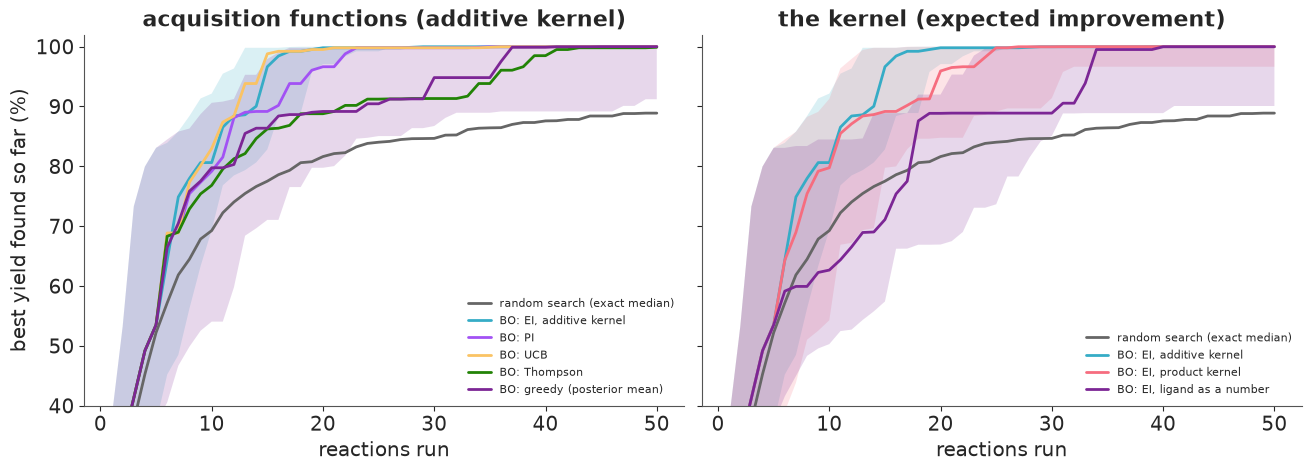

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
ax = axes[0]
ax.plot(ns[:T_BUDGET], med_random[:T_BUDGET], color="0.4", lw=2, label="random search (exact median)")
for k, col in [("BO: EI, additive kernel", "C0"), ("BO: PI", "C5"), ("BO: UCB", "C2"),
               ("BO: Thompson", "C4"), ("BO: greedy (posterior mean)", "C3")]:
    band(ax, CURVES[k], k, col, fill=k in ("BO: EI, additive kernel", "BO: greedy (posterior mean)"))
ax.set(xlabel="reactions run", ylabel="best yield found so far (%)", ylim=(40, 102),
       title="acquisition functions (additive kernel)")
ax.legend(fontsize=8, loc="lower right")
ax = axes[1]
ax.plot(ns[:T_BUDGET], med_random[:T_BUDGET], color="0.4", lw=2, label="random search (exact median)")
for k, col in [("BO: EI, additive kernel", "C0"), ("BO: EI, product kernel", "C1"),
               ("BO: EI, ligand as a number", "C3")]:
    band(ax, CURVES[k], k, col)
ax.set(xlabel="reactions run", title="the kernel (expected improvement)")
ax.legend(fontsize=8, loc="lower right");

**Acquisition functions** (left). EI, UCB and PI behave much alike (UCB is 2.3 points behind EI after
20 reactions, an interval that includes 0; PI 3.6 behind). Two rules fail in opposite directions:

* **Greedy** (posterior mean only) is **over-exploitation**: it finds a good region and keeps refining
  it. Its median best sits at 89% from about 17 to 30 reactions - the X-Phos plateau (X-Phos's best
  reaction gives 89%) - and it is 10 points behind EI after 20 reactions.
* **Thompson sampling** over-explores here: with 1,728 candidates and a posterior sd of 20-30 points
  on most of them, the maximum of one posterior draw is usually a reaction whose *noise* happened to be
  high in that draw. It is 8 points behind EI. E66's bandits had a handful of arms; the same rule is
  much less efficient when the arms are many and uncertain.

**Kernels and encodings** (right). The product kernel is 6 points behind the additive one after 20
reactions (90% interval 3-10). The **ligand-as-a-number** encoding is the real failure: it is *behind
random search* for the first 15 or so reactions (median best 63% after 10 reactions against 69% for
random search), 14 points behind the categorical kernel after 20, and it needs a median of 27
reactions to reach 95% against 15. Why?

ligand-as-a-number fit after 10 reactions: rho_ligand = 0.43  (the correlation between the first and last ligand in the alphabet)


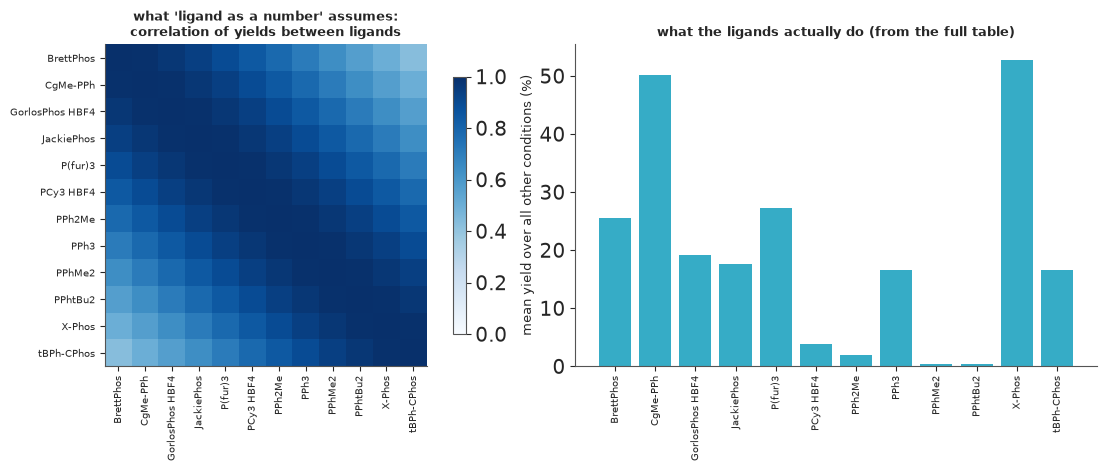

In [25]:
ex = RUNS["BO: EI, ligand as a number"][0]
h_num = ex["hyper"][5]
print("ligand-as-a-number fit after 10 reactions: rho_ligand =", round(float(h_num["rho"][0]), 3),
      " (the correlation between the first and last ligand in the alphabet)")
R_num = h_num["rho"][0] ** sq_dist("number")[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
im = axes[0].imshow(R_num, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(range(12), LEV[0], rotation=90, fontsize=7)
axes[0].set_yticks(range(12), LEV[0], fontsize=7)
axes[0].set_title("what 'ligand as a number' assumes:\ncorrelation of yields between ligands", fontsize=9)
plt.colorbar(im, ax=axes[0], shrink=0.8)
lig_mean = df.groupby("ligand")["yield"].mean().reindex(LEV[0])
axes[1].bar(range(12), lig_mean, color="C0")
axes[1].set_xticks(range(12), LEV[0], rotation=90, fontsize=7)
axes[1].set_ylabel("mean yield over all other conditions (%)", fontsize=9)
axes[1].set_title("what the ligands actually do (from the full table)", fontsize=9);

After 10 reactions the fitted correlation between the first and last ligands of the alphabet is 0.43,
so two *neighbouring* ligands (1/11 apart) are assumed correlated at $0.43^{1/121} \approx 0.99$ - the
model believes adjacent names in the alphabet are practically interchangeable. On the right, what the
ligands actually do: the two best (CgMe-PPh, second in the list; X-Phos, eleventh) sit next to
ligands that give almost nothing. A good result for X-Phos raises the posterior for PPhtBu2 next to
it, a poor one for PPhMe2 drags X-Phos down, and EI spends reactions on the consequences.

**The fix** is the categorical kernel of Part B: every pair of ligands equally related a priori, with
the correlation *learned*. The general rule: an encoding is a prior. Numbering categories invents an
order and a distance that do not exist, and a smooth kernel takes them literally.

### Can chemistry supply a real distance between ligands?

A chemist would object that ligands *are* related - by size, electronics, structure. Shields et al.
computed **DFT descriptors** for every ligand. Replace the alphabetical distance with the Euclidean
distance between standardised descriptor vectors, scaled two ways so that the Beta(2, 2) prior on
$\rho$ means something sensible (the largest, or the median, pair distance set to 1).

In [26]:
dft = data.load("edbo_arylation_ligand_dft").set_index("ligand").reindex(LEV[0])
Z = dft.loc[:, dft.std() > 0]
Z = ((Z - Z.mean()) / Z.std()).to_numpy()
D_desc = np.sum((Z[:, None, :] - Z[None, :, :]) ** 2, -1)       # squared distance between ligands
iu = np.triu_indices(12, 1)
print(f"{Z.shape[1]} non-constant DFT descriptors per ligand; median pair distance / largest: "
      f"{np.median(D_desc[iu]) / D_desc.max():.2f}")
print("Spearman correlation of descriptor distance with |difference in ligand mean yield|:",
      round(stats.spearmanr(D_desc[iu], np.abs(lig_mean.values[:, None] - lig_mean.values[None, :])[iu])[0], 2))
print("nearest neighbour in descriptor space:",
      {LEV[0][i]: LEV[0][np.argsort(D_desc[i])[1]] for i in np.argsort(-lig_mean.values)[:3]})
tic = time.time()
for scale, name in [("max", "BO: EI, descriptors (largest distance = 1)"),
                    ("median", "BO: EI, descriptors (median distance = 1)")]:
    Dn = D_desc / (D_desc.max() if scale == "max" else np.median(D_desc[iu]))
    RUNS[name] = run_many(MapFitter(*gp_model("additive", encoding="descriptors", lig_desc=Dn)), acq="ei")
    CURVES[name] = best_curves(RUNS[name])
print(f"{2 * NCAMP} campaigns: {time.time() - tic:.0f} s")
print(pd.DataFrame({k: {**summarise(CURVES[k], (10, 20, 30)), "vs EI-additive @20": paired(CURVES[k], 20)}
                    for k in ["BO: EI, additive kernel", "BO: EI, descriptors (largest distance = 1)",
                              "BO: EI, descriptors (median distance = 1)",
                              "BO: EI, ligand as a number"]}).T.to_string())

311 non-constant DFT descriptors per ligand; median pair distance / largest: 0.39
Spearman correlation of descriptor distance with |difference in ligand mean yield|: -0.07
nearest neighbour in descriptor space: {'X-Phos': 'PPhtBu2', 'CgMe-PPh': 'GorlosPhos HBF4', 'P(fur)3': 'PPhtBu2'}


100 campaigns: 17 s
                                           median best @10       P(>=95%) @10 median best @20       P(>=95%) @20 median best @30       P(>=95%) @30    vs EI-additive @20
BO: EI, additive kernel                             80.625  0.22 [0.14, 0.33]           99.81  0.80 [0.69, 0.87]           99.98  0.86 [0.76, 0.92]   +0.0 [ +0.0,  +0.0]
BO: EI, descriptors (largest distance = 1)          79.745  0.24 [0.16, 0.35]           96.64  0.62 [0.50, 0.72]           99.98  0.86 [0.76, 0.92]   -3.3 [ -6.2,  -0.3]
BO: EI, descriptors (median distance = 1)           80.625  0.16 [0.10, 0.27]           99.22  0.62 [0.50, 0.72]          99.895  0.82 [0.71, 0.89]   -4.7 [ -8.2,  -1.5]
BO: EI, ligand as a number                          62.665  0.08 [0.04, 0.17]          88.855  0.24 [0.16, 0.35]           88.89  0.44 [0.33, 0.56]  -13.9 [-17.7, -10.4]


Descriptors did not help here. Both scalings are 3-5 points behind the plain categorical kernel after
20 reactions ($P(\geq 95\%)$ 0.62 against 0.80), although far better than numbering. The first
printed lines say why: over the 66 pairs of ligands, descriptor distance is unrelated to how
differently they perform (Spearman correlation -0.07), and X-Phos's nearest neighbour in descriptor
space is PPhtBu2, a ligand that gives nothing anywhere. A similarity kernel is only useful if the
similarity it encodes is similarity *in the response*; 311 generic descriptors, weighted equally, need
not be. (Shields et al.'s own GP used descriptors differently - as inputs with a lengthscale for each
- and their campaigns did well in Part E; our comparison is about this simple kernel, not their method.
Checking a descriptor set on past reactions before trusting it is cheap.)

## G. Batches: five reactions per round

A robot or a plate runs several reactions at once, so a real campaign chooses a **batch** per round.
Two ways to fill a batch of $q = 5$ from one posterior:

* **kriging believer**: choose the EI maximum, *pretend* its yield came back equal to the posterior
  mean, update the posterior (not the hyperparameters), choose again. The pretend observation shrinks
  the sd around the first choice, so the next choice goes elsewhere.
* **Thompson sampling**: take the maxima of five independent posterior draws (drawing again if two
  coincide). Batching is free - the draws are independent.

The price of batching is measured in reactions (a batch cannot use the results of its own members);
the gain in rounds (wall-clock time).

100 batch campaigns: 7 s
                                  median best @10       P(>=95%) @10 median best @20       P(>=95%) @20 median best @30       P(>=95%) @30
BO: EI, additive kernel                    80.625  0.22 [0.14, 0.33]           99.81  0.80 [0.69, 0.87]           99.98  0.86 [0.76, 0.92]
batch of 5: kriging believer (EI)           77.55  0.16 [0.10, 0.27]           99.22  0.64 [0.52, 0.74]           99.81  0.78 [0.67, 0.86]
batch of 5: Thompson                        69.82  0.12 [0.07, 0.22]          88.775  0.30 [0.21, 0.42]           97.51  0.58 [0.46, 0.69]


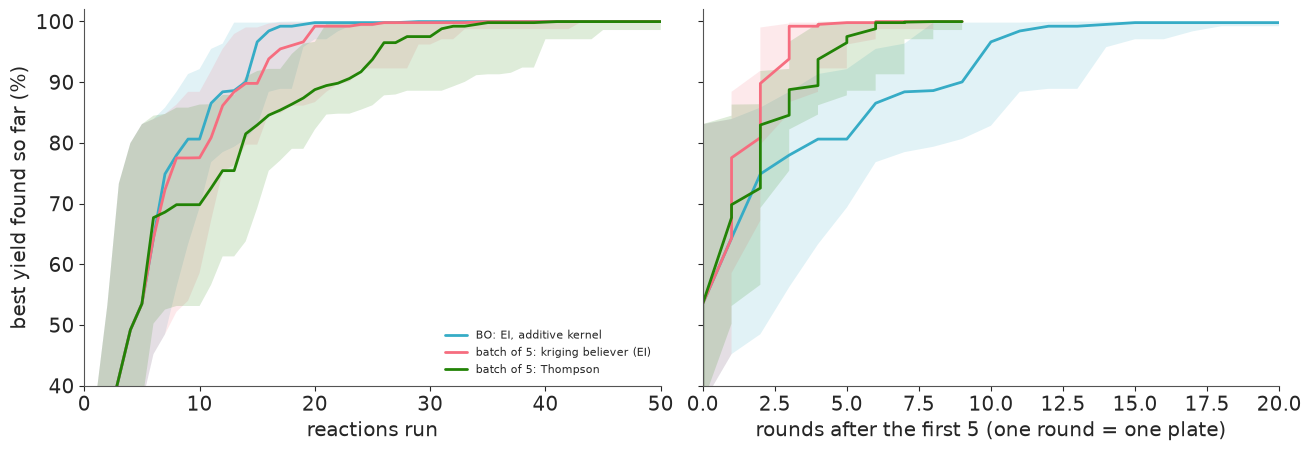

In [27]:
tic = time.time()
for acq, name in [("ei", "batch of 5: kriging believer (EI)"), ("ts", "batch of 5: Thompson")]:
    RUNS[name] = run_many(fit_add, acq=acq, q=5)
    CURVES[name] = best_curves(RUNS[name])
print(f"{2 * NCAMP} batch campaigns: {time.time() - tic:.0f} s")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, per in zip(axes, [1, 5]):
    for k, col, q in [("BO: EI, additive kernel", "C0", 1), ("batch of 5: kriging believer (EI)", "C1", 5),
                      ("batch of 5: Thompson", "C4", 5)]:
        C = CURVES[k]
        x = np.arange(1, T_BUDGET + 1)
        rounds = np.where(x <= N0, 0, np.ceil((x - N0) / q))
        xx = x if per == 1 else rounds
        med = np.median(C, 0)
        ax.plot(xx, med, color=col, lw=2, label=k)
        ax.fill_between(xx, np.quantile(C, 0.25, 0), np.quantile(C, 0.75, 0), color=col, alpha=0.15, lw=0)
    ax.set(xlabel="reactions run" if per == 1 else "rounds after the first 5 (one round = one plate)",
           xlim=(0, T_BUDGET if per == 1 else 20), ylim=(40, 102))
axes[0].set_ylabel("best yield found so far (%)")
axes[0].legend(fontsize=8, loc="lower right")
print(pd.DataFrame({k: summarise(CURVES[k], (10, 20, 30)) for k in
                    ["BO: EI, additive kernel", "batch of 5: kriging believer (EI)",
                     "batch of 5: Thompson"]}).T.to_string())

**Per reaction** (left), the kriging believer loses little: median best 99.2% after 20 reactions vs
99.8% sequentially, $P(\geq 95\%)$ 0.64 vs 0.80. Thompson batches are much worse (median 89% after 20),
for the over-exploration reason of Part F. **Per round** (right), batching wins easily: the kriging
believer's median campaign has a reaction near 99% after 3 plates (20 reactions), while one reaction
per round needs about 15 rounds for the same. When a round is a day in the lab, that is what matters.

## H. Noisy yields and the incumbent problem

The table gives one yield per reaction and we have treated it as the truth. Real yields are measured
with error, and a campaign that keeps the best **observed** yield suffers from the **winner's curse**
(E66): the reaction that looked best is partly the one that got lucky. A what-if: the black box now
returns the recorded yield plus Normal noise with sd 10 points (simulated; the table itself is left
as the truth), and we ask two questions:

1. **what to report**: the best *observed* yield, the true yield of that reaction, or the true yield of
   the reaction with the highest *posterior mean* (the model's recommendation, which pools the
   evidence from similar reactions)?
2. **which incumbent** EI should try to beat: the best observed yield (standard, and inflated by noise)
   or the best posterior mean among the reactions run ("plug-in" EI).

100 noisy campaigns: 15 s
after 20: claimed 105.2, truth of best-observed 95.5, truth of best-mean 98.4 (EI vs observed incumbent) | 96.6 (EI vs mean incumbent); paired mean diff (mean - observed incumbent) +0.8 [90%: -3.8, +5.6]
after 50: claimed 110.8, truth of best-observed 98.4, truth of best-mean 99.2 (EI vs observed incumbent) | 99.2 (EI vs mean incumbent); paired mean diff (mean - observed incumbent) +0.8 [90%: -0.7, +2.3]


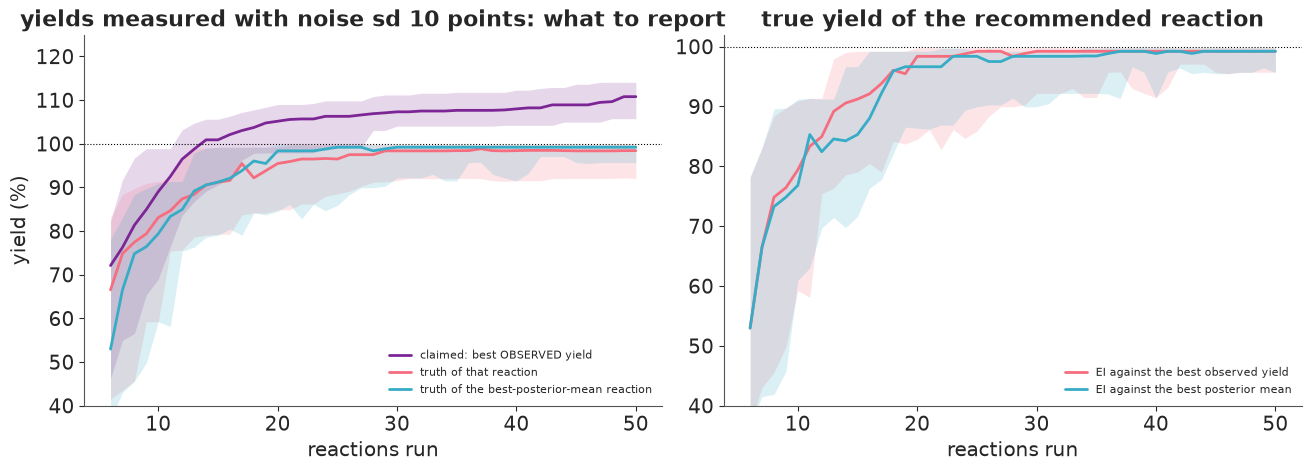

In [28]:
NOISE = 10.0
tic = time.time()
noisy_obs = run_many(fit_add, acq="ei", noise_sd=NOISE)
noisy_pm = run_many(fit_add, acq="ei", noise_sd=NOISE, incumbent="mean")
print(f"{2 * NCAMP} noisy campaigns: {time.time() - tic:.0f} s")


def recommend_curves(runs):
    """True yield of (a) the reaction with the best OBSERVED yield, (b) the one with the best posterior mean."""
    obs = np.array([[Y[r["sel"][int(np.argmax(r["y_obs"][:n]))]] for n in range(N0 + 1, T_BUDGET + 1)]
                    for r in runs])
    pmn = np.array([r["rec"] for r in runs])
    claimed = np.array([[np.max(r["y_obs"][:n]) for n in range(N0 + 1, T_BUDGET + 1)] for r in runs])
    return obs, pmn, claimed


obs_a, pm_a, claim_a = recommend_curves(noisy_obs)
obs_b, pm_b, claim_b = recommend_curves(noisy_pm)
xs = np.arange(N0 + 1, T_BUDGET + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
band(ax, np.c_[np.full((NCAMP, N0), np.nan), claim_a], "claimed: best OBSERVED yield", "C3")
band(ax, np.c_[np.full((NCAMP, N0), np.nan), obs_a], "truth of that reaction", "C1")
band(ax, np.c_[np.full((NCAMP, N0), np.nan), pm_a], "truth of the best-posterior-mean reaction", "C0")
ax.axhline(Y.max(), color="k", ls=":", lw=0.8)
ax.set(xlabel="reactions run", ylabel="yield (%)", ylim=(40, 125),
       title=f"yields measured with noise sd {NOISE:.0f} points: what to report")
ax.legend(fontsize=8, loc="lower right")
ax = axes[1]
band(ax, np.c_[np.full((NCAMP, N0), np.nan), pm_a], "EI against the best observed yield", "C1")
band(ax, np.c_[np.full((NCAMP, N0), np.nan), pm_b], "EI against the best posterior mean", "C0")
ax.axhline(Y.max(), color="k", ls=":", lw=0.8)
ax.set(xlabel="reactions run", ylim=(40, 102), title="true yield of the recommended reaction")
ax.legend(fontsize=8, loc="lower right")
for n in [20, 50]:
    j = n - N0 - 1
    d = pm_b[:, j] - pm_a[:, j]
    lo, hi = np.quantile(rng.choice(d, (4000, NCAMP)).mean(1), [0.05, 0.95])
    print(f"after {n}: claimed {np.median(claim_a[:, j]):.1f}, truth of best-observed "
          f"{np.median(obs_a[:, j]):.1f}, truth of best-mean {np.median(pm_a[:, j]):.1f} "
          f"(EI vs observed incumbent) | {np.median(pm_b[:, j]):.1f} (EI vs mean incumbent); "
          f"paired mean diff (mean - observed incumbent) {d.mean():+.1f} [90%: {lo:+.1f}, {hi:+.1f}]")

**What to report** (left): the best *observed* yield climbs past 100% - after 20 reactions the median
claim is 105%, after 50 it is 111% - while the true yield of that reaction is 95.5% and then 98.4%.
The more reactions, the more chances for a lucky measurement, so the maximum of noisy yields is
biased upwards and the bias *grows* with the campaign. The reaction with the highest **posterior
mean** is a better recommendation (true yield 98.4% after 20 reactions, 99.2% after 50): the model
pools the evidence from similar reactions and discounts a single lucky value. In practice: report the
posterior mean, or re-run the apparent winner.

**Which incumbent for EI** (right): measuring improvement against the best posterior mean instead of
the best noisy observation made no clear difference here (paired mean difference +0.8 points, 90%
interval about -4 to +6 after 20 reactions). The inflated observed incumbent could make EI too
pessimistic, but with the GP's noise term estimated from the data the effect was small in this
setting.

## I. When to stop

Real campaigns end when the budget does, or when further reactions look pointless. The model offers an
obvious signal: the **largest expected improvement** over all untested reactions, in yield points,
before each choice. "Stop when max EI < 1 point" sounds principled. Is it safe? We have the truth, so
we can check. We also try a **joint** question that EI cannot answer (EI is about one reaction at a
time): the posterior probability that *some* untested reaction beats the best so far by more than 5
points, from 200 joint Thompson draws of the whole surface, checked every 5 reactions.

                                                       rule  reactions: median 10-90% never stopped  regret at stop: median P(regret > 5)
                                  max EI < 2 point(s), once               13.0  10-20          0.00                    11.4          0.58
                                  max EI < 1 point(s), once               18.5  11-31          0.00                     0.8          0.40
                                max EI < 0.5 point(s), once               26.5  15-48          0.08                     0.0          0.24
                    max EI < 1 point for 5 choices in a row               31.0  17-45          0.08                     0.0          0.22
P(some untested reaction > best + 5) < 0.1, checked every 5               50.0  25-50          0.74                     0.0          0.06

P(beat by 5) when the best found was already 100%: median 0.47


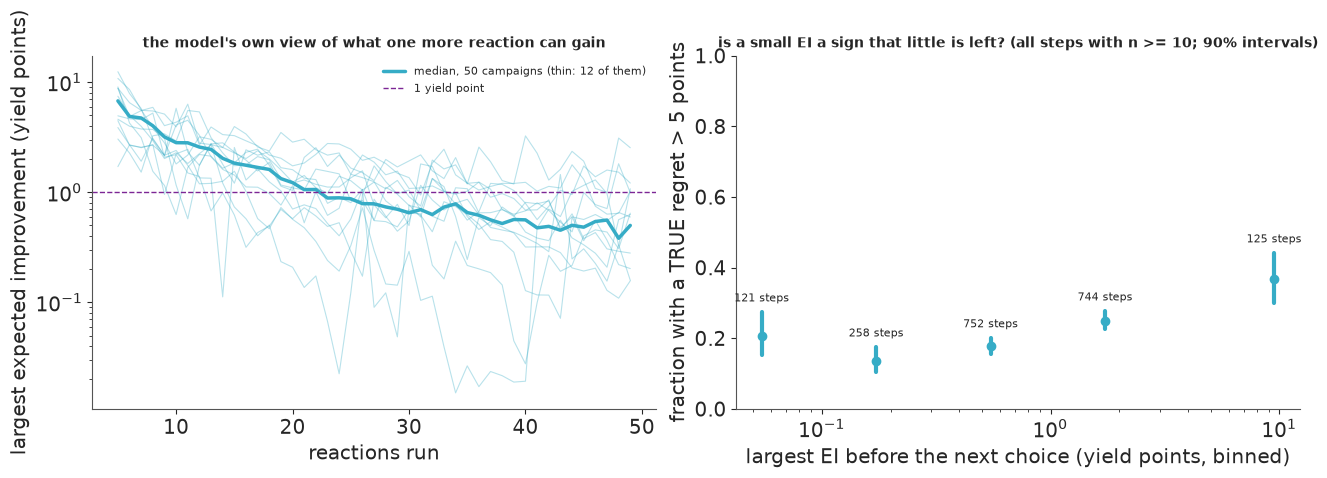

In [29]:
runs = RUNS["BO: EI, additive kernel"]
MAXEI = np.array([r["max_ei"] for r in runs])                # before choosing reaction n + 1, n = 5 .. 49
BEST = CURVES["BO: EI, additive kernel"][:, N0 - 1:T_BUDGET - 1]
REG = Y.max() - BEST
steps = np.arange(N0, T_BUDGET)

# a joint question the EI cannot answer: is there ANY untested reaction > 5 points better?
rng_s = np.random.default_rng(RANDOM_SEED)
CHECK = np.arange(10, T_BUDGET, 5)
P_BEAT = np.zeros((NCAMP, len(CHECK)))
for i, r in enumerate(runs):
    for j, n in enumerate(CHECK):
        sel_n = r["sel"][:n]
        ys_n, m_n, s_n = standardise(Y[sel_n])
        h = r["hyper"][n - N0]
        _, _, cache = gp_posterior(h, d2_cat, sel_n, ys_n)
        dr = posterior_surface(h, d2_cat, sel_n, ys_n, cache, rng_s, k=200) * s_n + m_n
        dr[:, sel_n] = -np.inf
        P_BEAT[i, j] = np.mean(dr.max(1) > Y[sel_n].max() + 5)


def first_stop(cond, at):
    """First n (at >= 10) where cond holds; T_BUDGET if never."""
    ok = cond & (at >= 10)
    return at[np.argmax(ok)] if ok.any() else T_BUDGET


rules = {}
for thr in [2.0, 1.0, 0.5]:
    rules[f"max EI < {thr:g} point(s), once"] = [first_stop(e < thr, steps) for e in MAXEI]
run5 = [np.convolve(e < 1.0, np.ones(5), "valid") == 5 for e in MAXEI]
rules["max EI < 1 point for 5 choices in a row"] = [first_stop(r_, steps[4:]) for r_ in run5]
rules["P(some untested reaction > best + 5) < 0.1, checked every 5"] = [
    first_stop(p_ < 0.1, CHECK) for p_ in P_BEAT]
rows = []
for name, stop in rules.items():
    stop = np.array(stop)
    reg = np.array([Y.max() - np.max(Y[r["sel"][:s_]]) for r, s_ in zip(runs, stop)])
    rows.append({"rule": name, "reactions: median": np.median(stop),
                 "10-90%": f"{np.quantile(stop, 0.1):.0f}-{np.quantile(stop, 0.9):.0f}",
                 "never stopped": f"{np.mean(stop == T_BUDGET):.2f}",
                 "regret at stop: median": round(np.median(reg), 1),
                 "P(regret > 5)": f"{np.mean(reg > 5):.2f}"})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nP(beat by 5) when the best found was already 100%: median {np.median(P_BEAT[REG[:, CHECK - N0] < 0.01]):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
for i in range(12):
    ax.semilogy(steps, MAXEI[i], color="C0", alpha=0.35, lw=0.8)
ax.semilogy(steps, np.median(MAXEI, 0), color="C0", lw=2.5, label="median, 50 campaigns (thin: 12 of them)")
ax.axhline(1.0, color="C3", ls="--", lw=1, label="1 yield point")
ax.set(xlabel="reactions run", ylabel="largest expected improvement (yield points)")
ax.set_title("the model's own view of what one more reaction can gain", fontsize=10)
ax.legend(fontsize=8)
ax = axes[1]
edges = np.array([0, 0.1, 0.3, 1, 3, 30])
m10 = steps >= 10
e_all, bad = MAXEI[:, m10].ravel(), (REG[:, m10] > 5).ravel()
for lo_, hi_ in zip(edges[:-1], edges[1:]):
    w = (e_all >= lo_) & (e_all < hi_)
    k, n_ = bad[w].sum(), w.sum()
    lo, hi = stats.beta(1 + k, 1 + n_ - k).ppf([0.05, 0.95])
    x_ = np.sqrt(max(lo_, 0.03) * hi_)
    ax.plot([x_, x_], [lo, hi], color="C0", lw=3)
    ax.plot(x_, k / n_, "o", color="C0")
    ax.text(x_, hi + 0.03, f"{n_} steps", ha="center", fontsize=8)
ax.set(xscale="log", ylim=(0, 1), xlabel="largest EI before the next choice (yield points, binned)",
       ylabel="fraction with a TRUE regret > 5 points")
ax.set_title("is a small EI a sign that little is left? (all steps with n >= 10; 90% intervals)", fontsize=10);

**Expected-improvement thresholds are not safe stopping rules.** The median largest EI drops below one
yield point at about 22 reactions, but single campaigns cross that line early and often. Stopping the
first time it happens (from 10 reactions on) ends a campaign after a median of 18.5 reactions - and in
40% of campaigns with a true regret above 5 points. A stricter threshold (0.5) or requiring five small
values in a row lowers that to 22-24% and delays the stop to 26-31 reactions. The right panel shows the
underlying problem: over all steps, the chance that more than 5 points were still to be found is
14-37% *whatever the EI* (steps of the same campaign are not independent, so these intervals are too
narrow). Three reasons:

1. EI is the expected gain of **one** reaction; the value of continuing is the gain of the best of
   many.
2. It is computed from a posterior that cannot know about interactions it has seen no hint of (in
   Part B, the best reactions sat 2-3 sd above the posterior mean), and the MAP plug-in's sd is too
   small on top of that.
3. The GP on raw yields does not know yields are bounded (last line of the table).

The **joint** rule - stop when the posterior probability that *any* untested reaction beats the best by
5 points drops below 0.1 - is safe (6% of campaigns with regret above 5 at stopping) but hardly ever
fires: 74% of campaigns never stop within 50 reactions. After finding a 100% reaction the model still
gives about a 50% chance of beating it by 5 points, because to a Gaussian process 105% is just another
number. Stopping rules need a model that knows the scale (Try it yourself 1) and an explicit cost of
one more experiment; until then, a fixed budget is the honest rule.

## J. What did the surrogate learn?

Optimisation is not only about the best reaction. After 50 reactions (the demo campaign), what does the
surrogate know about the chemistry? We refit with NUTS and summarise posterior draws of the whole
surface two ways: the **spread of each factor's level averages** (how much the average yield changes
between its levels - a model-free measure of importance we can also compute from the full table), and
the **average yield of each ligand**.

                    mean    sd  eti89_lb  eti89_ub  ess_bulk  r_hat
amp[ligand]         0.53  0.28      0.10      1.00   1721.38    1.0
amp[base]           0.25  0.25      0.02      0.71   3946.52    1.0
amp[solvent]        0.30  0.28      0.02      0.83   3916.74    1.0
amp[concentration]  0.65  0.50      0.05      1.58   2423.39    1.0
amp[temperature]    0.77  0.55      0.08      1.79   1932.41    1.0
rho[ligand]         0.23  0.14      0.05      0.47   3899.53    1.0
rho[base]           0.60  0.16      0.31      0.83   3044.78    1.0
rho[solvent]        0.55  0.19      0.22      0.82   2538.61    1.0
rho[concentration]  0.67  0.19      0.32      0.91   3532.62    1.0
rho[temperature]    0.34  0.14      0.12      0.57   3372.18    1.0
eta                 0.81  0.18      0.55      1.11   1741.48    1.0
sigma               0.12  0.10      0.01      0.33   1715.11    1.0
divergences: 0


               posterior median    5%   95%  full table
ligand                     21.1  15.0  27.7        17.0
base                        4.5   1.3   8.8         2.9
solvent                     6.5   2.1  13.1         7.1
concentration               4.4   0.7  10.3         1.0
temperature                 8.8   1.7  18.0         4.3
of the 50 reactions: 39 at 0.153 M, 32 at 120 C
total run time 196 s


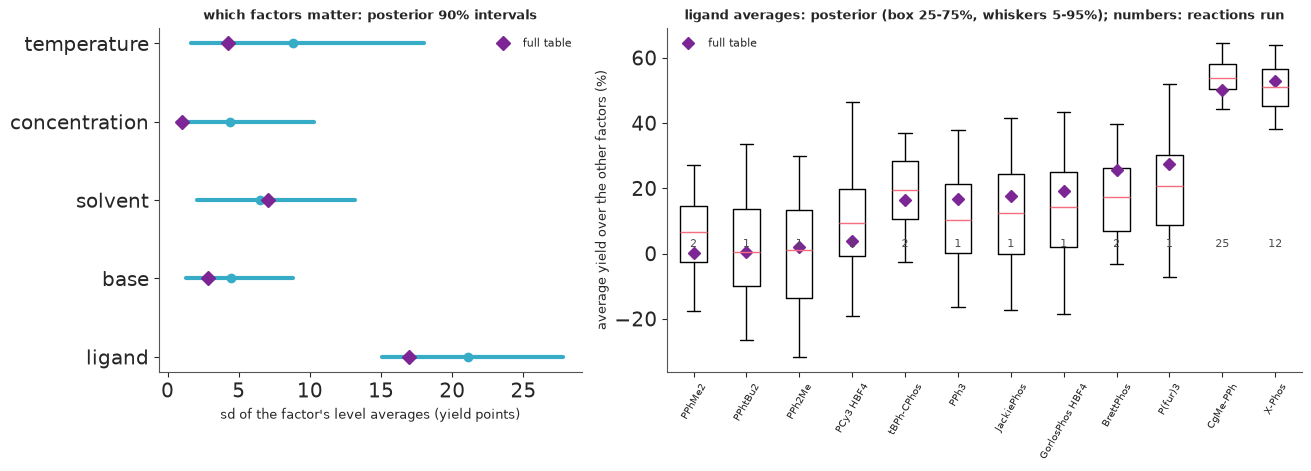

In [30]:
sel50 = demo["sel"]
ys50, m50, s50 = standardise(Y[sel50])
m_j, _ = gp_model("additive", n0=T_BUDGET)
pm.set_data({"idx": IDX[sel50], "y": ys50}, model=m_j)
with m_j:
    idata50 = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(idata50, var_names=["amp", "rho", "eta", "sigma"], round_to=2)
      [["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]].to_string())
print("divergences:", int(idata50.sample_stats["diverging"].sum()))

post50 = az.extract(idata50, num_samples=200, random_seed=RANDOM_SEED)
rng_j = np.random.default_rng(RANDOM_SEED)
surf = []
for i in range(200):
    h = {k: post50[k].values[..., i] for k in ["c", "sigma", "eta", "amp", "rho"]}
    _, _, cache = gp_posterior(h, d2_cat, sel50, ys50)
    surf.append(posterior_surface(h, d2_cat, sel50, ys50, cache, rng_j)[0] * s50 + m50)
surf = np.array(surf)


def effect_sd(v):
    """Spread (sd across levels) of the average yield at each level of each factor."""
    v = v.reshape(-1, *NL)
    return np.array([v.mean(axis=tuple(a + 1 for a in range(5) if a != f)).std(-1) for f in range(5)]).T


eff_post = effect_sd(surf)
eff_true = effect_sd(Y[None])[0]
print(pd.DataFrame({"posterior median": np.median(eff_post, 0), "5%": np.quantile(eff_post, 0.05, 0),
                    "95%": np.quantile(eff_post, 0.95, 0), "full table": eff_true}, index=FACT).round(1).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), width_ratios=[1, 1.5])
ax = axes[0]
for f in range(5):
    lo, med, hi = np.quantile(eff_post[:, f], [0.05, 0.5, 0.95])
    ax.plot([lo, hi], [f, f], color="C0", lw=3)
    ax.plot(med, f, "o", color="C0")
    ax.plot(eff_true[f], f, "D", color="C3", ms=7, label="full table" if f == 0 else None)
ax.set_yticks(range(5), FACT)
ax.set_xlabel("sd of the factor's level averages (yield points)", fontsize=9)
ax.set_title("which factors matter: posterior 90% intervals", fontsize=9)
ax.legend(fontsize=8)
ax = axes[1]
lig_post = surf.reshape(-1, *NL).mean(axis=(2, 3, 4, 5))
o = np.argsort(lig_mean.values)
ax.boxplot(lig_post[:, o], positions=np.arange(12), widths=0.5, showfliers=False,
           whis=(5, 95))
ax.plot(np.arange(12), lig_mean.values[o], "D", color="C3", label="full table")
n_tested = np.bincount(IDX[sel50, 0], minlength=12)[o]
print("of the 50 reactions:", np.sum(IDX[sel50, 3] == 2), "at 0.153 M,", np.sum(IDX[sel50, 4] == 2), "at 120 C")
for i, n_ in enumerate(n_tested):
    ax.text(i, 2, f"{n_}", ha="center", fontsize=8, color="0.3")
ax.set_xticks(range(12), np.array(LEV[0])[o], rotation=60, fontsize=7)
ax.set_ylabel("average yield over the other factors (%)", fontsize=9)
ax.set_title("ligand averages: posterior (box 25-75%, whiskers 5-95%); numbers: reactions run",
             fontsize=9)
ax.legend(fontsize=8)
print(f"total run time {time.time() - T_START:.0f} s")

* **Which factors matter** (left): the posterior ranks the ligand first by a wide margin (level
  averages spread by about 21 points, 90% 15-28; the full table: 17), and the full-table values of
  the other four factors fall inside their 90% intervals. But the intervals for temperature and
  concentration are wide and their medians too high (9 vs 4, 4 vs 1): an sd across three levels
  estimated with error is biased upwards, and 50 reactions chosen to *optimise* are not a design for
  estimating effects - most were run at 0.153 M and 120 C.
* **Ligand averages** (right): CgMe-PPh (25 reactions) and X-Phos (12) are pinned down within a few
  points of their true averages. The other ten ligands were run once or twice each, and their averages
  are uncertain by 20-30 points - wide enough to include negative yields, which a Gaussian model does
  not forbid. The truth lies within the 5-95% whiskers for all twelve.

That asymmetry is the exploration-exploitation trade-off seen from the other side: a campaign that
finds the optimum quickly is a poor survey of the space. If the goal is understanding (which ligands
work, for a paper or for the next substrate), use a design for that, or add an information-based
acquisition.

## Summary

* **Bayesian optimisation = a surrogate, an acquisition function and a loop.** On a real, fully
  measured table of 1,728 reactions it found a reaction above 95% in 80% of campaigns within 20
  experiments (median 15 to get there), against 11% for random search, 16% for one factor at a time and
  32% for 50 chemists playing the same game, and matched the authors' published method.
* **The surrogate for mixed factors** is a product of small per-factor correlation matrices (exchangeable
  for categories, squared-exponential for ordered levels). Parameterised by correlations with Beta
  priors it is readable, it equals a one-hot ARD kernel (checked against `pm.gp.cov`), and on a grid its
  Kronecker structure gives exact joint posterior draws cheaply via Matheron's rule.
* **Structure is a prior, and it matters.** Adding explicit main effects to the product kernel (a GP
  ANOVA) was worth 6 points of best yield after 20 reactions. Encoding the ligand as a number invented
  a false similarity and made BO worse than random search for the first 15 or so reactions. Generic DFT
  descriptors were no better than no descriptors, because their distances did not track yield.
* **Acquisition functions**: EI, UCB and PI were close; pure exploitation stalled on a local plateau and
  Thompson sampling over-explored a large, uncertain space.
* **Cheap inference was adequate for choosing**: a MAP refit on the compiled PyMC model took
  milliseconds; 16 fully Bayesian campaigns (NUTS after every reaction) were not better. The MAP
  posterior sd was about a quarter too small.
* **Batches** of five by kriging believer cost little per reaction and saved most of the rounds;
  Thompson batches did not.
* **Noise**: the best observed yield overstated the truth by 10 points after 20 reactions (105% claimed);
  recommend by posterior mean.
* **Stopping**: "stop when EI < 1 point" stopped too early in 40% of campaigns; a joint probability was
  safe but almost never stopped, because a GP does not know yields end at 100%. The model's own view of
  what is left is only as good as the model.

## Try it yourself

1. **A model that knows yields are bounded.** Fit the GP to a transformed yield (e.g. logit of
   (yield + 1)/102) or put a Beta or censored likelihood on the latent GP, and rerun Parts E and I. Does
   the joint stopping rule now stop - and safely? Does anything change in the benchmark?
2. **Paying for experiments.** Give each reaction a cost of $c$ yield points and stop when the expected
   gain from the *best of the next five* reactions (from joint Thompson draws, as in Part I) falls below
   $5c$. For $c$ = 0.5 and 2, how many reactions does a campaign use, and what is the expected regret
   plus cost, compared with fixed budgets of 20, 30 and 50?
3. **Another reaction.** The EDBO repository also holds full tables for a Suzuki-Miyaura coupling
   (Perera et al. 2018) and a Buchwald-Hartwig amination (Ahneman et al. 2018). Load one with the pattern
   of `tools/build_e82_arylation.py`, compute its ANOVA as in Part A, and rerun Part E. Is the additive
   kernel still better than the product kernel when interactions carry more of the variance?